In [1]:
print('Running imports...')
import os
from captum.attr import IntegratedGradients

os.environ["MKL_THREADING_LAYER"] = "GNU"

import torch # long
from lightning.pytorch import seed_everything
from torch import nn 

import xarray as xr
from tqdm import tqdm
import pandas as pd
import seaborn as sns
import numpy as np
import seaborn.objects as so
import dask.bag as db
import argparse
import matplotlib.pyplot as plt
import sys
sys.path.append('/home/rogui7909/code/predict_rain_norway/predict_rain')

from ml_module_rain.models.trained_models import load_trained_model


Running imports...


In [ ]:
# from dask.distributed import Client, LocalCluster

# cluster = LocalCluster(
#     n_workers=16,
#     threads_per_worker=1,
#     memory_limit='4GB',
#     scheduler_port=0,  # use random available port
# )

# client = Client(cluster)

: 

# Load trained model

In [2]:
run_id = '740gigv5'
samples_to_attribute = 'extr'
torch.set_float32_matmul_precision('medium')
seed_everything(42, workers=True)
dataloader, lightning_model = load_trained_model(run_id)

Seed set to 42


Data ready:
    Image size: 16380 (182x90)
    Input variables: u850, msl, z500, v850
    21732 samples in train
    4657 samples in validation
    4658 samples in test
    4 Predicted timesteps for future rainfall
    Prediction type: boolean_smooth
    What quantile is considered extreme: 90th of rainy days


# Compute predictions

In [3]:
all_targets = []
all_preds = []
for batch in tqdm(dataloader.val_loader):
    x, y = batch
    lightning_model.eval()
    with torch.no_grad():
        all_preds.append(lightning_model(x))
    all_targets.append(y)

100%|██████████| 9/9 [00:11<00:00,  1.32s/it]


In [4]:
targets = torch.cat(all_targets).cpu().numpy()
preds = torch.nn.Sigmoid()(torch.cat(all_preds)).cpu().numpy()

ds_aligned = dataloader.ds_val.isel(time=range(targets.shape[0]))
preds_da = xr.DataArray(preds, dims=['time','timestep'], coords =ds_aligned.targets.coords)
ds_aligned ['predictions'] = preds_da

(array([4184., 1941., 1476., 1291., 1276., 1394., 1621., 1716., 1870.,
        1663.]),
 array([3.06935253e-04, 1.00213945e-01, 2.00120956e-01, 3.00027966e-01,
        3.99934977e-01, 4.99841988e-01, 5.99749029e-01, 6.99656010e-01,
        7.99563050e-01, 8.99470091e-01, 9.99377072e-01]),
 <BarContainer object of 10 artists>)

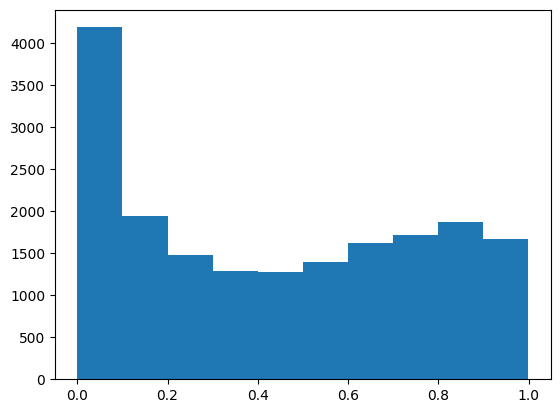

In [5]:
preds_da.plot.hist()

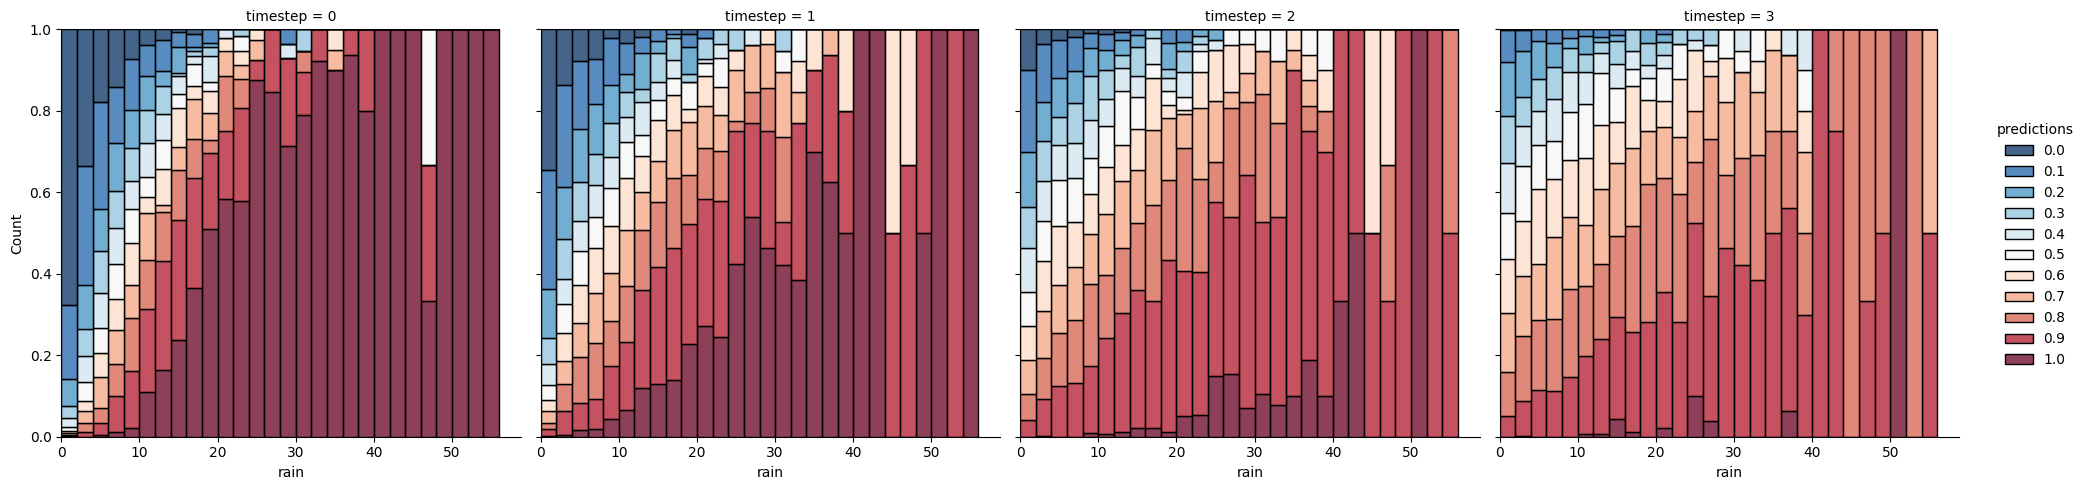

In [6]:
df_ = ds_aligned[['predictions','rain']].to_dataframe()
df_['predictions']=df_.predictions.round(1)

sns.displot(df_, x='rain', hue='predictions', multiple='fill', bins=np.arange(0,80,2), kind='hist', palette='RdBu_r', col='timestep')

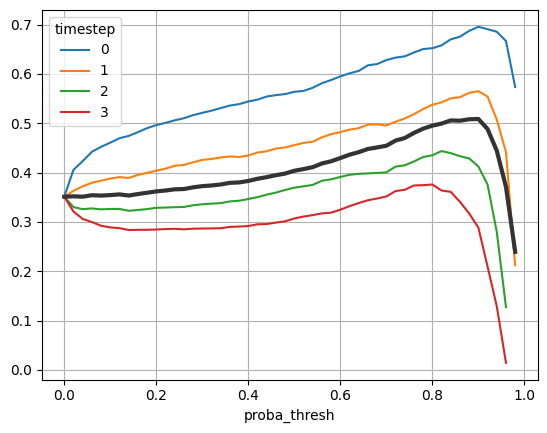

In [9]:
thresh = xr.DataArray(np.arange(0.,1.0001,.02), dims=['proba_thresh'], coords=dict(proba_thresh = np.arange(0.,1.0001,.02)))
TP = ((ds_aligned.predictions>thresh) & (ds_aligned.targets>thresh)).sum(['time'])
precision = TP/((ds_aligned.predictions>thresh)).sum(['time'])
recall = TP/(ds_aligned.targets>thresh).sum(['time'])
f1 = 2*recall*precision/(recall+precision)

f1.plot(hue='timestep');

thresh = xr.DataArray(np.arange(0.,1.0001,.02), dims=['proba_thresh'], coords=dict(proba_thresh = np.arange(0.,1.0001,.02)))
TP = ((ds_aligned.predictions>thresh) & (ds_aligned.targets>thresh)).sum(['time','timestep'])
precision = TP/((ds_aligned.predictions>thresh)).sum(['time','timestep'])
recall = TP/(ds_aligned.targets>thresh).sum(['time','timestep'])
f1 = 2*recall*precision/(recall+precision)

f1.plot(color='.2', lw=3);
# precision.plot()
# recall.plot()
plt.grid()

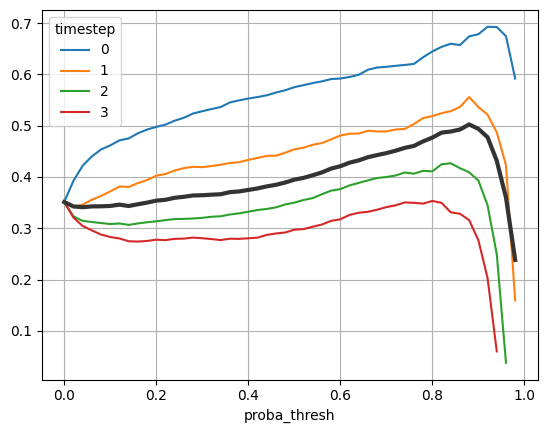

In [7]:
thresh = xr.DataArray(np.arange(0.,1.0001,.02), dims=['proba_thresh'], coords=dict(proba_thresh = np.arange(0.,1.0001,.02)))
TP = ((ds_aligned.predictions>thresh) & (ds_aligned.targets>thresh)).sum(['time'])
precision = TP/((ds_aligned.predictions>thresh)).sum(['time'])
recall = TP/(ds_aligned.targets>thresh).sum(['time'])
f1 = 2*recall*precision/(recall+precision)

f1.plot(hue='timestep');

thresh = xr.DataArray(np.arange(0.,1.0001,.02), dims=['proba_thresh'], coords=dict(proba_thresh = np.arange(0.,1.0001,.02)))
TP = ((ds_aligned.predictions>thresh) & (ds_aligned.targets>thresh)).sum(['time','timestep'])
precision = TP/((ds_aligned.predictions>thresh)).sum(['time','timestep'])
recall = TP/(ds_aligned.targets>thresh).sum(['time','timestep'])
f1 = 2*recall*precision/(recall+precision)

f1.plot(color='.2', lw=3);
# precision.plot()
# recall.plot()
plt.grid()

In [8]:

series_targets = ds_aligned.targets.to_series()
series_predictions = ds_aligned.predictions.to_series()
all_predictions = pd.DataFrame(dict(predictions=series_predictions, targets=series_targets)).reset_index()
all_predictions.columns = ['time_of_prediction','timestep','prediction','target']
all_predictions['time_of_event'] = all_predictions.time_of_prediction + all_predictions.timestep*pd.Timedelta(1,'D')
valid_times = all_predictions.groupby("time_of_event").target.count().reset_index().query(f"target=={dataloader.config['num_timesteps_predicted']}").time_of_event # Only four predictions
all_predictions = all_predictions.loc[all_predictions.time_of_event.isin(valid_times)]

ds_prediction = all_predictions.pivot(index='time_of_event', values=['target','prediction'], columns='timestep').stack().to_xarray()
ds_prediction = ds_prediction.assign_coords(timestep=np.arange(0,-4,-1))

time_of_attributions = ds_prediction.time_of_event
time_of_attributions = ds_prediction.time_of_event.where(ds_prediction.isel(timestep=0, drop=True).target == 1, drop=True)

/tmp/ipykernel_1170087/682035404.py:9: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ds_prediction = all_predictions.pivot(index='time_of_event', values=['target','prediction'], columns='timestep').stack().to_xarray()


In [9]:
steps = dataloader.config['num_timesteps_predicted']
start_times = (time_of_attributions-pd.Timedelta(3,'D')).dt.strftime("%Y-%m-%d %H:%M:%S").values
end_times = (time_of_attributions).dt.strftime("%Y-%m-%d %H:%M:%S").values
method = IntegratedGradients(lightning_model.model)
all_multi_attrs = []
all_multi_sens = []
for k in tqdm(range(len(start_times))):
    start = start_times[k]
    end = end_times[k]
    ds_test_extract =  ds_aligned.sel(time=slice(start ,end))
    tensor_in = torch.Tensor(ds_test_extract.features.values).requires_grad_()
    attrs = method.attribute(tensor_in, baselines=torch.Tensor([0]),target=[3,2,1,0]) 
    da_attrs = xr.DataArray(attrs.detach(), dims = ['timestep','var_name','latitude','longitude'], 
                                coords= dict(timestep=np.arange(1,steps+1),var_name=ds_test_extract.var_name, latitude=ds_test_extract.latitude, longitude=ds_test_extract.longitude))
#     # print(start,end)
#     ds_test_extract =  ds_aligned.sel(time=slice(start ,end))
#     tensor_in = torch.Tensor(ds_test_extract.features.values)
#     tensor_out = torch.Tensor(ds_test_extract.targets.values)
#     attrs = method.attribute(tensor_in, baselines=torch.Tensor([0]),target=[3*(steps-k)-1 for k in range(steps)]) 
#     da_attrs = xr.DataArray(attrs, dims = ['timestep','var_name','latitude','longitude'], 
#                             coords= dict(timestep=np.arange(1,steps+1),var_name=ds_test_extract.var_name, latitude=ds_test_extract.latitude, longitude=ds_test_extract.longitude))
    all_multi_attrs.append(da_attrs.assign_coords(time=time_of_attributions[k]))
    sens = da_attrs/ds_test_extract.features.rename(time='timestep').assign_coords(timestep=da_attrs.timestep)
    all_multi_sens.append(sens.assign_coords(time=time_of_attributions[k]))
    # break
timesteps = np.arange(-steps+1,1)
ds_attributions = xr.concat(all_multi_attrs, dim='time_of_event').assign_coords(timestep=timesteps)
ds_sens = xr.concat(all_multi_sens, dim='time_of_event').assign_coords(timestep=timesteps)
final_ds = xr.merge([xr.Dataset(dict(attributions = ds_attributions, sensitivity=ds_sens)), ds_prediction])

100%|██████████| 330/330 [01:52<00:00,  2.93it/s]


In [10]:
timesteps = np.arange(-steps+1,1)
ds_attributions = xr.concat(all_multi_attrs, dim='time_of_event').assign_coords(timestep=timesteps)
ds_sens = xr.concat(all_multi_sens, dim='time_of_event').assign_coords(timestep=timesteps)
final_ds = xr.merge([xr.Dataset(dict(attributions = ds_attributions, sensitivity=ds_sens)), ds_prediction.sel(time_of_event=ds_attributions.time_of_event)])
final_ds.to_netcdf(f"/Data/gfi/users/rogui7909/data/NN_outputs/attributions/{run_id}_attributions_extreme.nc")


(array([  7.,  18.,  13.,  26.,  50.,  72.,  92., 170., 298., 574.]),
 array([0.06190647, 0.15551059, 0.2491147 , 0.34271882, 0.43632294,
        0.52992705, 0.62353117, 0.71713528, 0.8107394 , 0.90434352,
        0.99794763]),
 <BarContainer object of 10 artists>)

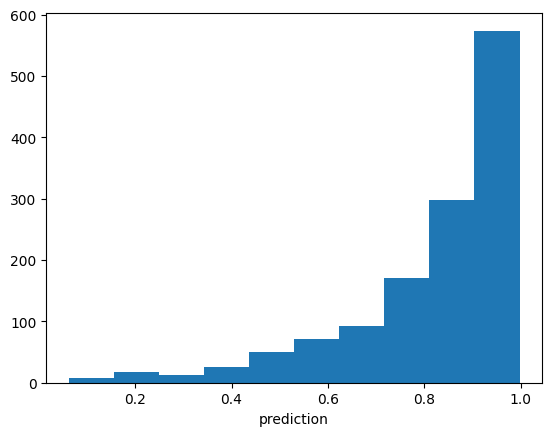

In [3]:
# run_id = 'lozkymt2'
# final_ds = xr.open_dataset(f"/Data/gfi/users/rogui7909/data/NN_outputs/attributions/{run_id}_attributions_extreme.nc")
# final_ds.prediction.plot.hist()

In [2]:
run_id = 'lozkymt2'

final_ds = xr.open_dataset(f"/Data/gfi/users/rogui7909/data/NN_outputs/attributions/{run_id}_attributions_extreme.nc")
final_ds['fields'] = final_ds.attributions/final_ds.sensitivity

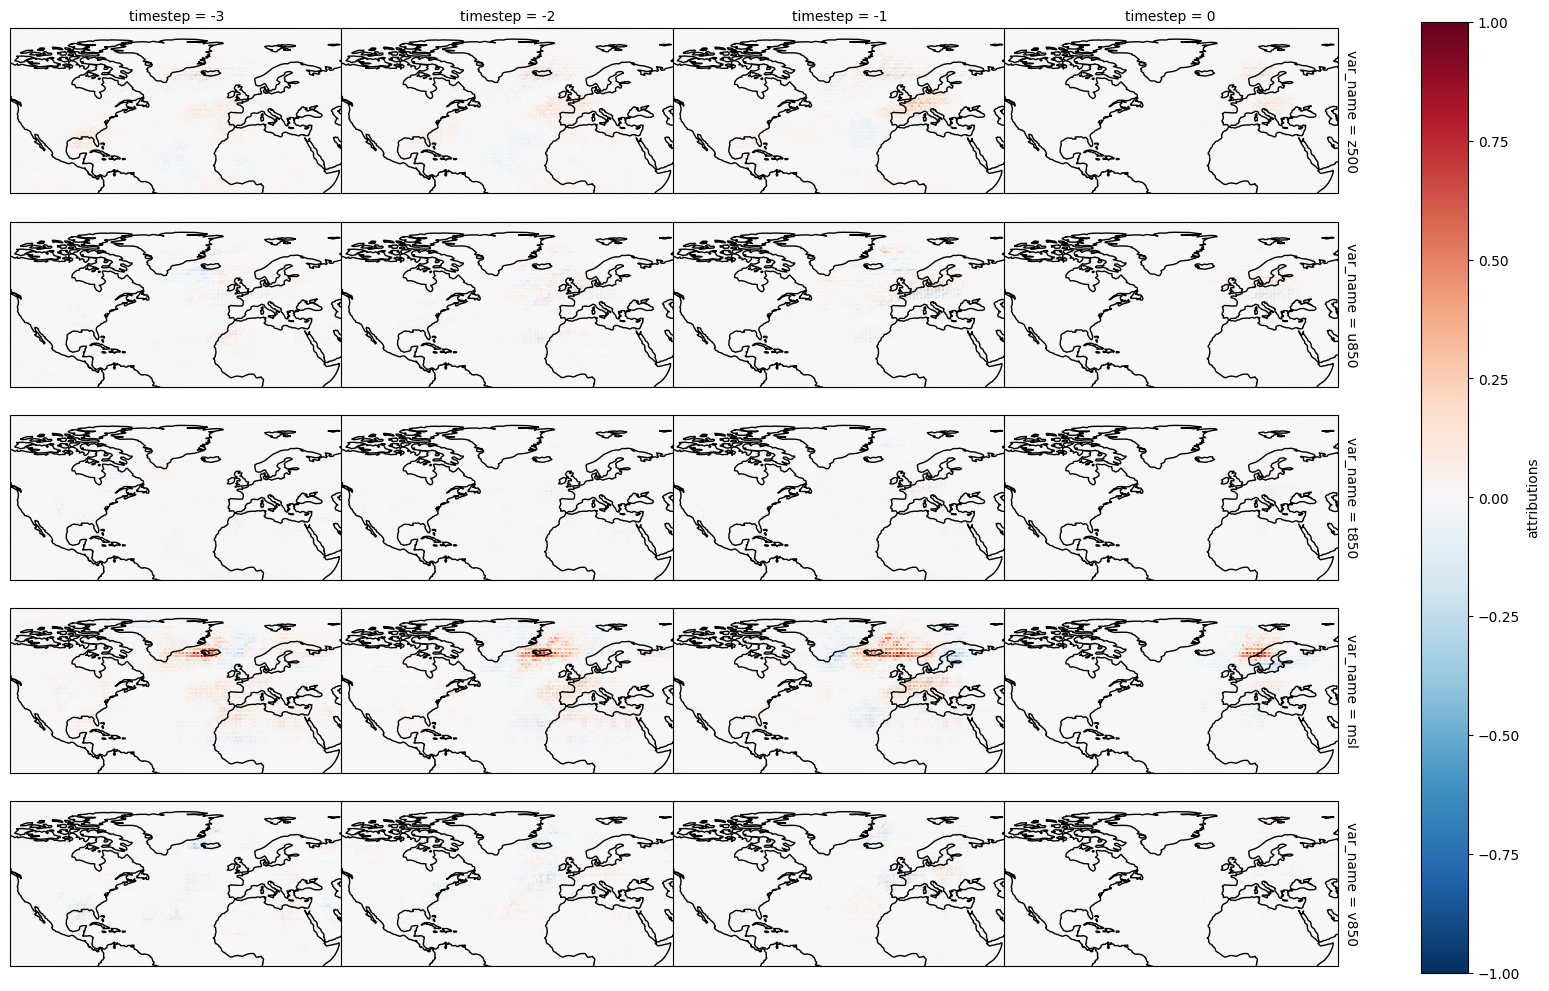

In [3]:
import cartopy.crs as ccrs
ds_ = final_ds.attributions.where((final_ds.prediction>0.9).sum('timestep') > 2, drop=True).isel(time_of_event=40)
plot = (ds_/ds_.max(['longitude','latitude','var_name'])).plot(col='timestep', row='var_name', subplot_kws = dict(projection=ccrs.PlateCarree()), aspect=2, size=2)
for ax in plot.axs.flatten():
    ax.coastlines()

In [ ]:
cycs = xr.open_dataset('/Data/gfi/spengler/kko033/cyclone_clustering/data/all_combined_NH_trcks.nc').to_dataframe().set_index('track_id').sort_index()
df_features = pd.read_csv("/Data/gfi/users/rogui7909/data/attribute_precip_features/western_norway/features_attributed_to_rain_per_day_WN.csv",index_col=0, parse_dates=True)
grid = xr.zeros_like(final_ds.attributions.isel(time_of_event=0, var_name=0, timestep=0, drop=True))

def get_cyclone_distance(date):
    pass

import numpy as np

def haversine_np(lon1, lat1, lon2, lat2, radius=6371):

    # Convert degrees to radians
    lon1 = np.radians(lon1)
    lat1 = np.radians(lat1)
    lon2 = np.radians(lon2)
    lat2 = np.radians(lat2)

    # Compute differences
    dlon = lon2 - lon1
    dlat = lat2 - lat1

    # Haversine formula
    a = np.sin(dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return radius * c

# distances_to_cyclone = haversine_np(cycs_extract_tracks.lon,cycs_extract_tracks.lat, grid.longitude, grid.latitude)

# min_distances_to_cyclone = distances_to_cyclone.groupby(distances_to_cyclone.time.dt.date.rename('time')).min()

In [6]:
date = '2001-10-29'

def get_distance_to_cyclone(date):
    date_min = (pd.to_datetime(date) - pd.Timedelta(3,'D')).strftime("%Y-%m-%d")
    features_date = df_features.loc[date].dropna().iloc[:-2]
    if features_date.size==0:
        # print("No feature")
        return
    cyclones_date = features_date.loc[features_date.str.startswith('C_')]
    if cyclones_date.size==0:
        # print("No cyclone")
        return
    cyclones_date = cyclones_date.str.split('_', expand=True).iloc[:,1].astype(int).values
    cycs_extract = cycs.loc[cyclones_date].set_index('date').sort_index()
    cycs_extract = cycs_extract.loc[date_min:date]
    cycs_extract = cycs_extract[['lon','lat']].to_xarray().rename(date='time')

    distance_to_cyclones = haversine_np(grid.longitude,grid.latitude, cycs_extract.lon, cycs_extract.lat)

    min_distances_to_cyclone = distance_to_cyclones.resample(time='D').min()
    min_distances_to_cyclone = min_distances_to_cyclone.assign_coords(time_of_event = pd.to_datetime(date))
    timesteps = (pd.to_datetime(min_distances_to_cyclone.time) - pd.to_datetime(date)).days
    min_distances_to_cyclone = min_distances_to_cyclone.rename(time='timestep').assign_coords(timestep=timesteps)
    return min_distances_to_cyclone



In [7]:
all_dist = []
days_str = final_ds.time_of_event.dt.strftime('%Y-%m-%d').values

for date in tqdm(days_str):
    dist = get_distance_to_cyclone(date)
    if dist is not None:
        all_dist.append(dist)
dist_to_cyclone = xr.concat(all_dist, dim='time_of_event')
final_ds['dist_to_cyclone'] = dist_to_cyclone


100%|██████████| 330/330 [00:12<00:00, 26.82it/s]


In [8]:
final_ds['distance_rank'] = final_ds.dist_to_cyclone.stack(space=['latitude','longitude']).rank('space', pct=True).unstack()

In [9]:
df_ = final_ds[['attributions','dist_to_cyclone','distance_rank','prediction']].to_dataframe().reset_index()

In [ ]:
attrs = final_ds.attributions.sum('var_name')
msl = final_ds.fields.sel(var_name='msl') 
from xarrayutils import xr_linregress
ds_2 = xr.Dataset(dict(attrs=attrs, msl=msl))
df__ = ds_2.to_dataframe().reset_index()


In [ ]:
sns.relplot(df__,x='msl',y='attrs', hue='var_name')

<Axes: xlabel='dist_to_cyclone', ylabel='distance_rank'>

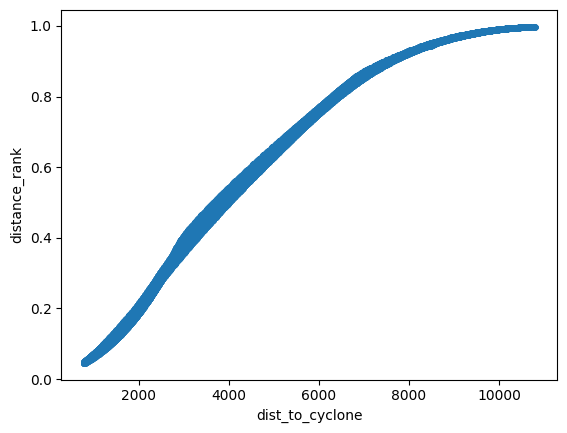

In [55]:
final_ds.mean(['time_of_event','timestep']).to_dataframe().plot.scatter(x='dist_to_cyclone', y='distance_rank', linewidth=0)

In [ ]:
summed_attrs.set_index('time').loc['1999-10-11']
summed_attrs['features_distance'] = [k.mid for k in summed_attrs.distance_rank]
# summed_attrs
plot = (so.Plot(summed_attrs.set_index('time').loc['1999-10-11'], x='features_distance', y='attributions', color='var_name')
 .add(so.Bar(),so.Stack())
 .facet(row='timestep')
 .layout(size=(4,6))
 .theme(plt.style.library["robin"])
 .theme({'axes.grid':True, 'grid.color':'.3'})
 .limit(x=(0,1))
 .label(x='Distance from cyclone', col='Day', y='Sum of attributions',)
 .show()
#  .share(x=True, y=False)
)

Process Dask Worker process (from Nanny):
2025-08-08 11:21:31,002 - distributed.nanny - ERROR - Worker process died unexpectedly
2025-08-08 11:21:31,013 - distributed.nanny - ERROR - Worker process died unexpectedly
Process Dask Worker process (from Nanny):
2025-08-08 11:21:31,014 - distributed.nanny - ERROR - Worker process died unexpectedly
Process Dask Worker process (from Nanny):
2025-08-08 11:21:31,014 - distributed.nanny - ERROR - Worker process died unexpectedly
2025-08-08 11:21:31,015 - distributed.nanny - ERROR - Worker process died unexpectedly
Process Dask Worker process (from Nanny):
Process Dask Worker process (from Nanny):
Process Dask Worker process (from Nanny):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/vol/vb_apps/software/Python/3.12.3-GCCcore-13.3.0/lib/python3.12/asyncio/runners.py", line 118, in run
    return self._loop.run_until_complete(task)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/vol/vb_apps/software/Python/

In [64]:
summed_attrs = df_.loc[df_.prediction>0.9].groupby(['timestep','var_name','time',pd.cut(df_.distance_rank, np.arange(0,1.001, .05))]).attributions.mean().reset_index()

/tmp/ipykernel_2941856/3053278665.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summed_attrs = df_.loc[df_.prediction>0.9].groupby(['timestep','var_name','time',pd.cut(df_.distance_rank, np.arange(0,1.001, .05))]).attributions.mean().reset_index()


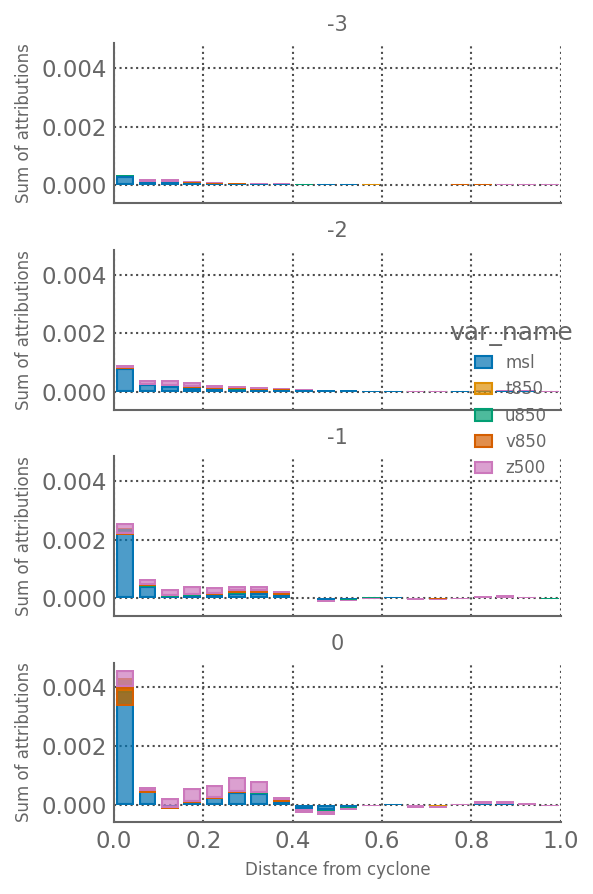

In [63]:
summed_attrs# summed_attrs = df_.groupby(['timestep','feature','var_name',pd.cut(df_.features_distance, np.arange(0,10000,200))]).attributions.sum().reset_index()
summed_attrs['features_distance'] = [k.mid for k in summed_attrs.distance_rank]
# summed_attrs
plot = (so.Plot(summed_attrs.set_index('time').loc['1999-10-11'], x='features_distance', y='attributions', color='var_name')
 .add(so.Bar(),so.Stack())
 .facet(row='timestep')
 .layout(size=(4,6))
 .theme(plt.style.library["robin"])
 .theme({'axes.grid':True, 'grid.color':'.3'})
 .limit(x=(0,1))
 .label(x='Distance from cyclone', col='Day', y='Sum of attributions',)
 .show()
#  .share(x=True, y=False)
)

In [ ]:
days_str = final_ds.time_of_event.dt.strftime('%Y-%m-%d').values
from dask import delayed, compute

tasks = [delayed(get_distance_to_cyclone)(date) for date in days_str]
results = compute(*tasks)


/Data/gfi/users/rogui7909/virtual_envs/ml-env/lib/python3.12/site-packages/distributed/client.py:3371: UserWarning: Sending large graph of size 295.47 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


No cyclone
No cyclone
No cyclone
No cyclone
No cyclone
No cyclone
No cyclone
No cyclone
No cyclone
No cyclone
No cyclone
No cyclone
No cyclone


2025-08-08 10:49:49,633 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 2.61 GiB -- Worker memory limit: 3.73 GiB
2025-08-08 10:49:53,914 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 2.62 GiB -- Worker memory limit: 3.73 GiB
2025-08-08 10:50:17,998 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- U

No cyclone


2025-08-08 10:50:23,826 - distributed.worker.memory - WARNING - Worker is at 80% memory usage. Pausing worker.  Process memory: 2.99 GiB -- Worker memory limit: 3.73 GiB
2025-08-08 10:50:24,894 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 2.61 GiB -- Worker memory limit: 3.73 GiB
2025-08-08 10:50:27,303 - distributed.worker.memory - WARNING - Worker is at 80% memory usage. Pausing worker.  Process memory: 3.01 GiB -- Worker memory limit: 3.73 GiB


In [14]:
dist_to_cyclone = xr.concat(results, dim='time_of_event')

/Data/gfi/users/rogui7909/virtual_envs/ml-env/lib/python3.12/site-packages/distributed/client.py:3371: UserWarning: Sending large graph of size 295.57 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
2025-08-08 10:40:23,893 - distributed.worker - ERROR - Compute Failed
Key:       ('from_sequence-get_distance_to_cyclone-e6573fc249d9332201362b95d3cfd8fa', 18)
State:     executing
Task:  <Task ('from_sequence-get_distance_to_cyclone-e6573fc249d9332201362b95d3cfd8fa', 18) _execute_subgraph(...)>
Exception: 'TypeError("<class \'xarray.core.dataarray.DataArray\'> is not convertible to datetime, at position 0")'
Traceback: '  File "/Data/gfi/users/rogui7909/virtual_envs/ml-env/lib/python3.12/site-packages/dask/bag/core.py", line 1872, in reify\n    seq = l

TypeError: <class 'xarray.core.dataarray.DataArray'> is not convertible to datetime, at position 0

In [6]:
all_times = final_ds.time_of_event + pd.Timedelta(1,'D')*xr.DataArray([-3,-2,-1,0], dims=['timestep'],coords=dict(timestep=[-3,-2,-1,0]))
# all_times.to_series().unique().date

In [7]:
cycs = xr.open_dataset('/Data/gfi/spengler/kko033/cyclone_clustering/data/all_combined_NH_trcks.nc')#.to_dataframe()
cycs = cycs.assign_coords(index=cycs.date.values)[['lon','lat', 'track_id']].rename(index='date')
cycs_extract = cycs.loc[dict(date=cycs.date.dt.date.isin(all_times.to_series().unique().date))].rename(date='time')

In [96]:
cycs = xr.open_dataset('/Data/gfi/spengler/kko033/cyclone_clustering/data/all_combined_NH_trcks.nc')#.to_dataframe()
cycs = cycs.assign_coords(index=cycs.date.values)[['lon','lat', 'track_id']].rename(index='date')


In [117]:
cycs = xr.open_dataset('/Data/gfi/spengler/kko033/cyclone_clustering/data/all_combined_NH_trcks.nc')#.to_dataframe()
cycs

<xarray.Dataset> Size: 324MB
Dimensions:             (index: 2061508)
Coordinates:
  * index               (index) int64 16MB 0 1 2 3 4 ... 6914 6918 6920 6922
Data variables: (12/20)
    track_id            (index) int32 8MB ...
    date                (index) datetime64[ns] 16MB ...
    segment_len         (index) float64 16MB ...
    movement_speed      (index) float64 16MB ...
    movement_direction  (index) float64 16MB ...
    lon                 (index) float64 16MB ...
    ...                  ...
    msl_mingrad         (index) float64 16MB ...
    msl_maxlap          (index) float64 16MB ...
    cluster_id          (index) int64 16MB ...
    bjerknes_id         (index) int64 16MB ...
    stagnant_id         (index) int64 16MB ...
    solo_cyc            (index) int64 16MB ...

In [104]:
final_ds['fields'].time_of_event

<xarray.DataArray 'time_of_event' (time_of_event: 330)> Size: 3kB
array(['1999-07-21T00:00:00.000000000', '1999-10-10T00:00:00.000000000',
       '1999-10-11T00:00:00.000000000', ..., '2011-12-26T00:00:00.000000000',
       '2012-01-10T00:00:00.000000000', '2012-01-11T00:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time_of_event  (time_of_event) datetime64[ns] 3kB 1999-07-21 ... 2012-01-11
    time           (time_of_event) datetime64[ns] 3kB ...

In [112]:
final_ds['fields'].sel(time_of_event='2011-12-26').sel(var_name='msl')

<xarray.DataArray 'fields' (timestep: 4, latitude: 90, longitude: 182)> Size: 262kB
array([[[ 3.48395556e-01,  3.40453804e-01,  3.32220286e-01, ...,
          4.43404645e-01,  4.49044883e-01,  4.47363287e-01],
        [ 3.44741285e-01,  3.45338404e-01,  3.44341993e-01, ...,
          4.52004671e-01,  4.57189798e-01,  4.57237095e-01],
        [ 3.42912734e-01,  3.48656088e-01,  3.50628108e-01, ...,
          4.80587661e-01,  4.80815947e-01,  4.73259538e-01],
        ...,
        [-3.29597384e-01, -3.53046596e-01, -3.76234025e-01, ...,
          2.13816851e-01,  2.37359390e-01,  2.60757923e-01],
        [-1.45175099e-01, -1.61574319e-01, -1.77791297e-01, ...,
          2.18611673e-01,  2.34311551e-01,  2.49898359e-01],
        [ 6.61720615e-03, -1.57060416e-03, -9.80014261e-03, ...,
          1.85314298e-01,  1.93518758e-01,  2.01666698e-01]],

       [[ 6.41958833e-01,  6.41321599e-01,  6.32978976e-01, ...,
          4.92027313e-01,  4.81310695e-01,  4.66741651e-01],
        [ 6.43070936e-01,  6.51701629e-01,  6.49446368e-01, ...,
          5.25670886e-01,  5.18613338e-01,  5.07663667e-01],
        [ 6.48666024e-01,  6.58927441e-01,  6.58996403e-01, ...,
          5.55132210e-01,  5.47687173e-01,  5.38483560e-01],
...
         -9.79863405e-02, -7.26721883e-02, -4.71051671e-02],
        [ 1.56780517e+00,  1.55451691e+00,  1.54108691e+00, ...,
          3.84723037e-01,  4.00147736e-01,  4.15985495e-01],
        [ 1.38951421e+00,  1.38261473e+00,  1.37568152e+00, ...,
          7.93024540e-01,  8.00478518e-01,  8.07992339e-01]],

       [[ 5.03302693e-01,  4.97457981e-01,  4.90295589e-01, ...,
          5.23709595e-01,  5.23797274e-01,  5.21237791e-01],
        [ 4.97162223e-01,  4.97061759e-01,  4.96447772e-01, ...,
          5.52998006e-01,  5.48690617e-01,  5.46046674e-01],
        [ 4.86363560e-01,  4.91721034e-01,  4.95613813e-01, ...,
          5.82277775e-01,  5.78275025e-01,  5.74373484e-01],
        ...,
        [ 1.63890028e+00,  1.63026559e+00,  1.62136900e+00, ...,
         -9.31722701e-01, -9.23529923e-01, -9.14996564e-01],
        [ 1.33473372e+00,  1.32967842e+00,  1.32456505e+00, ...,
         -3.98062557e-01, -3.93208981e-01, -3.87819409e-01],
        [ 9.76923466e-01,  9.74366248e-01,  9.71765041e-01, ...,
          1.03526175e-01,  1.06187291e-01,  1.08988479e-01]]],
      dtype=float32)
Coordinates:
    var_name       <U4 16B 'msl'
  * latitude       (latitude) float64 720B 0.0 1.0 2.0 3.0 ... 87.0 88.0 89.0
  * longitude      (longitude) float64 1kB -128.0 -127.0 -126.0 ... 52.0 53.0
    time_of_event  datetime64[ns] 8B 2011-12-26
    time           datetime64[ns] 8B ...
  * timestep       (timestep) int64 32B -3 -2 -1 0

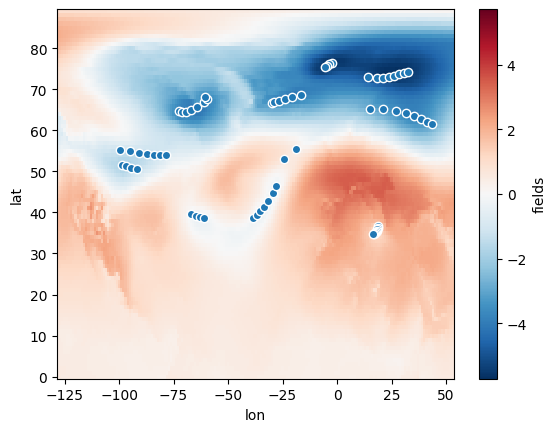

In [113]:
final_ds['fields'].sel(time_of_event='2011-12-26').sel(var_name='msl', timestep=0).plot()
cycs.sel(date='2011-12-26').plot.scatter(x='lon',y='lat')

In [57]:
df_features = pd.read_csv("/Data/gfi/users/rogui7909/data/attribute_precip_features/western_norway/features_attributed_to_rain_per_day_WN.csv",index_col=0, parse_dates=True)
df_features_extr = df_features.loc[final_ds.time_of_event]
all_cyclones = df_features_extr.stack().where(df_features_extr.stack().str.startswith('C_')).dropna().str.split('_', expand=True).iloc[:,1]
all_cyclones = all_cyclones.loc[all_cyclones!='F'].rename('track_id').reset_index()

cyclone_tracks = all_cyclones.track_id.unique()

cycs_extract_tracks = cycs_extract.where(cycs_extract.track_id.isin(cyclone_tracks.astype(int)), drop=True)

In [72]:
import numpy as np

def haversine_np(lon1, lat1, lon2, lat2, radius=6371):

    # Convert degrees to radians
    lon1 = np.radians(lon1)
    lat1 = np.radians(lat1)
    lon2 = np.radians(lon2)
    lat2 = np.radians(lat2)

    # Compute differences
    dlon = lon2 - lon1
    dlat = lat2 - lat1

    # Haversine formula
    a = np.sin(dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return radius * c

distances_to_cyclone = haversine_np(cycs_extract_tracks.lon,cycs_extract_tracks.lat, grid.longitude, grid.latitude)

min_distances_to_cyclone = distances_to_cyclone.groupby(distances_to_cyclone.time.dt.date.rename('time')).min()

In [129]:
dist_cyclone = xr.concat([min_distances_to_cyclone.shift(time=k).assign_coords(timestep=-k) for k in range(4)], dim='timestep').rename(time='time_of_event').sortby('timestep')
dist_cyclone['time_of_event'] = pd.to_datetime(dist_cyclone['time_of_event'])

In [132]:
dist_cyclones = dist_cyclone.where(dist_cyclone.time_of_event.isin(final_ds.time_of_event), drop=True)

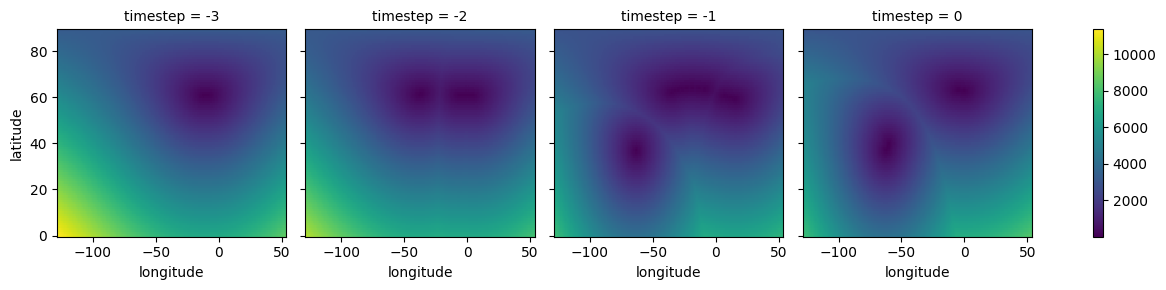

In [140]:
dist_cyclones.sel(time_of_event=final_ds.time_of_event.isel(time_of_event=50)).plot(col='timestep')

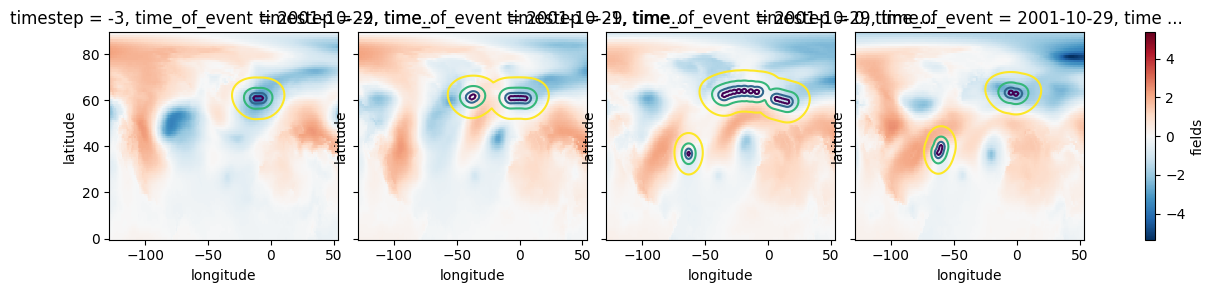

In [143]:
plot = final_ds.fields.isel(time_of_event=50).sel(var_name='msl').plot(col='timestep')
for k, ax in enumerate(plot.axs.flatten()):
    dist_cyclones.sel(time_of_event=final_ds.time_of_event.isel(time_of_event=50)).isel(timestep=k).plot.contour(ax=ax, levels=[100,250,500,1000])


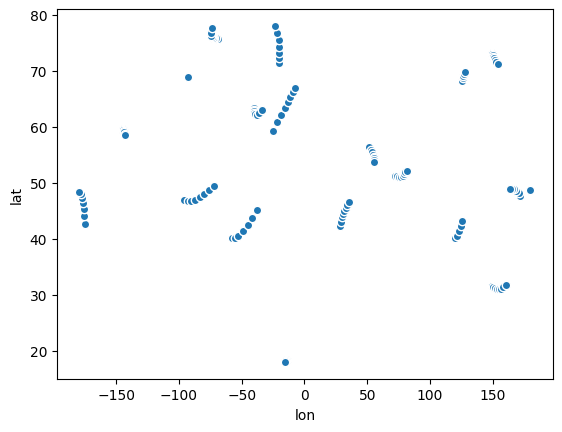

In [34]:
date = '2000-01-01' 
cycs_extract.sel(time=date).plot.scatter(x='lon', y='lat')

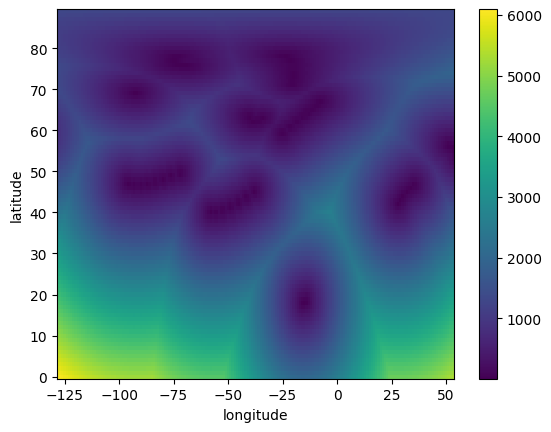

In [22]:
cycs_extract.sel(time='2000-05-01')
get_distance('2000-01-01').plot()

In [ ]:
grid = xr.zeros_like(final_ds.attributions.isel(time_of_event=0, var_name=0, timestep=0, drop=True))
import dask.bag as db

def get_distance(date):
    return haversine_np(grid.longitude,grid.latitude, cycs_extract.sel(time=date).lon, cycs_extract.sel(time=date).lat)

list_k = np.arange(cycs_extract.time.size)
bag = db.from_sequence(list_k)
results = bag.map(get_distance)
distances = xr.concat(results)

In [9]:
import dask.array as da
def haversine_dask(lon1, lat1, lon2, lat2):
    """
    Computes haversine distance between two sets of points using dask arrays.
    Assumes lon/lat are in degrees.
    All inputs must be broadcastable to the same shape.
    """
    # Convert to radians
    lon1 = da.radians(lon1)
    lat1 = da.radians(lat1)
    lon2 = da.radians(lon2)
    lat2 = da.radians(lat2)

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = da.sin(dlat / 2) ** 2 + da.cos(lat1) * da.cos(lat2) * da.sin(dlon / 2) ** 2
    c = 2 * da.arcsin(da.sqrt(a))

    R = 6371.0  # Earth radius in km
    return R * c

In [12]:

grid = xr.zeros_like(final_ds.attributions.isel(time_of_event=0, var_name=0, timestep=0, drop=True)).chunk(longitude=-1).expand_dims(time=cycs_extract.time.size).chunk(time=1000).assign_coords(time=cycs_extract.time)
# grid = grid.expand_dims(date=cycs.date).chunk(dict(date=100))
distance_to_cyclones = haversine_dask(grid.longitude,grid.latitude, cycs_extract.lon, cycs_extract.lat)

KeyboardInterrupt: 

Process Dask Worker process (from Nanny):
2025-08-08 09:39:36,264 - distributed.nanny - ERROR - Worker process died unexpectedly
Process Dask Worker process (from Nanny):
2025-08-08 09:39:36,264 - distributed.nanny - ERROR - Worker process died unexpectedly
Process Dask Worker process (from Nanny):
2025-08-08 09:39:36,265 - distributed.nanny - ERROR - Worker process died unexpectedly
Process Dask Worker process (from Nanny):
2025-08-08 09:39:36,265 - distributed.nanny - ERROR - Worker process died unexpectedly
2025-08-08 09:39:36,266 - distributed.nanny - ERROR - Worker process died unexpectedly
Process Dask Worker process (from Nanny):
2025-08-08 09:39:36,267 - distributed.nanny - ERROR - Worker process died unexpectedly
2025-08-08 09:39:36,267 - distributed.nanny - ERROR - Worker process died unexpectedly
Process Dask Worker process (from Nanny):
Process Dask Worker process (from Nanny):
2025-08-08 09:39:36,268 - distributed.nanny - ERROR - Worker process died unexpectedly
Process Da

In [ ]:
xr.zeros_like(final_ds.attributions.isel(time_of_event=0, var_name=0, timestep=0, drop=True)).chunk(longitude=-1).expand_dims(time=cycs_extract.date.size).chunk(time=1000).assign_coords(time=cycs_extract.date)

<xarray.DataArray 'attributions' (time: 117104, latitude: 90, longitude: 182)> Size: 8GB
dask.array<rechunk-merge, shape=(117104, 90, 182), dtype=float32, chunksize=(1000, 90, 182), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float64 720B 0.0 1.0 2.0 3.0 ... 86.0 87.0 88.0 89.0
  * longitude  (longitude) float64 1kB -128.0 -127.0 -126.0 ... 51.0 52.0 53.0
Dimensions without coordinates: time

In [ ]:
cycs = xr.open_dataset('/Data/gfi/spengler/kko033/cyclone_clustering/data/all_combined_NH_trcks.nc', chunks = dict(time=1000))#.to_dataframe()
cycs = cycs.assign_coords(index=cycs.date.values)[['lon','lat']].rename(index='date')
cycs_extract = cycs.loc[dict(date=cycs.date.dt.date.isin(all_times.to_series().unique().date))].rename(date='time')
grid = xr.zeros_like(final_ds.attributions.isel(time_of_event=0, var_name=0, timestep=0, drop=True)).chunk(longitude=-1).expand_dims(time=cycs_extract.time.size).chunk(time=1000).assign_coords(time=cycs_extract.time)
# grid = grid.expand_dims(date=cycs.date).chunk(dict(date=100))
# distance_to_cyclones = haversine_np(grid.longitude,grid.latitude, cycs.lon, cycs.lat).load()

In [27]:
cycs.loc[dict(date=cycs.date.dt.date.isin(all_times.to_series().unique().date))]

<xarray.Dataset> Size: 3MB
Dimensions:  (date: 117104)
Coordinates:
  * date     (date) datetime64[ns] 937kB 1999-07-18 ... 2012-01-11T21:00:00
Data variables:
    lon      (date) float64 937kB dask.array<chunksize=(117104,), meta=np.ndarray>
    lat      (date) float64 937kB dask.array<chunksize=(117104,), meta=np.ndarray>

<xarray.Dataset> Size: 3MB
Dimensions:  (date: 117104)
Coordinates:
  * date     (date) datetime64[ns] 937kB 1999-07-18 ... 2012-01-11T21:00:00
Data variables:
    lon      (date) float64 937kB dask.array<chunksize=(117104,), meta=np.ndarray>
    lat      (date) float64 937kB dask.array<chunksize=(117104,), meta=np.ndarray>

<xarray.Dataset> Size: 324MB
Dimensions:             (index: 2061508)
Coordinates:
  * index               (index) datetime64[ns] 16MB 1979-01-01 ... 2022-12-31...
Data variables: (12/20)
    track_id            (index) int32 8MB dask.array<chunksize=(2061508,), meta=np.ndarray>
    date                (index) datetime64[ns] 16MB dask.array<chunksize=(2061508,), meta=np.ndarray>
    segment_len         (index) float64 16MB dask.array<chunksize=(2061508,), meta=np.ndarray>
    movement_speed      (index) float64 16MB dask.array<chunksize=(2061508,), meta=np.ndarray>
    movement_direction  (index) float64 16MB dask.array<chunksize=(2061508,), meta=np.ndarray>
    lon                 (index) float64 16MB dask.array<chunksize=(2061508,), meta=np.ndarray>
    ...                  ...
    msl_mingrad         (index) float64 16MB dask.array<chunksize=(2061508,), meta=np.ndarray>
    msl_maxlap          (index) float64 16MB dask.array<chunksize=(2061508,), meta=np.ndarray>
    cluster_id          (index) int64 16MB dask.array<chunksize=(2061508,), meta=np.ndarray>
    bjerknes_id         (index) int64 16MB dask.array<chunksize=(2061508,), meta=np.ndarray>
    stagnant_id         (index) int64 16MB dask.array<chunksize=(2061508,), meta=np.ndarray>
    solo_cyc            (index) int64 16MB dask.array<chunksize=(2061508,), meta=np.ndarray>

In [ ]:
cycs_pos = cycs.loc[(cycs.date.dt.date.isin(all_times.to_series().unique().date))][['date','lon','lat']].set_index('date').to_xarray()
grid = xr.zeros_like(final_ds.attributions.isel(time_of_event=0, var_name=0, timestep=0, drop=True))#.expand_dims(time=cycs_extract.day.unique())
grid = grid.expand_dims(date=cycs_pos.date).chunk(dict(date=100))
distance_to_cyclones = haversine_np(grid.longitude,grid.latitude, cycs_pos.lon, cycs_pos.lat).load()

In [10]:
cycs_pos = cycs.loc[(cycs.date.dt.date.isin(all_times.to_series().unique().date))][['date','lon','lat']].set_index('date').to_xarray()
grid = xr.zeros_like(final_ds.attributions.isel(time_of_event=0, var_name=0, timestep=0, drop=True))#.expand_dims(time=cycs_extract.day.unique())
grid = grid.expand_dims(date=cycs_pos.date).chunk(dict(date=100))
distance_to_cyclones = haversine_np(grid.longitude,grid.latitude, cycs_pos.lon, cycs_pos.lat).load()

In [ ]:
min_distance_per_day = distance_to_cyclones.groupby(distance_to_cyclones.date.dt.date).min()

In [3]:
df_features = pd.read_csv("/Data/gfi/users/rogui7909/data/attribute_precip_features/western_norway/features_attributed_to_rain_per_day_WN.csv",index_col=0, parse_dates=True)


In [4]:
df_features

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,rain_type,daily_rain
time,,,,,,,,,,,,,,,,,,
1979-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NoFeature,0.048363
1979-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NoFeature,0.098712
1979-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NoFeature,0.073075
1979-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NoFeature,0.381240
1979-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NoFeature,5.288073
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-12-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NoFeature,15.205207
2022-12-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NoFeature,1.321124
2022-12-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NoFeature,12.620945


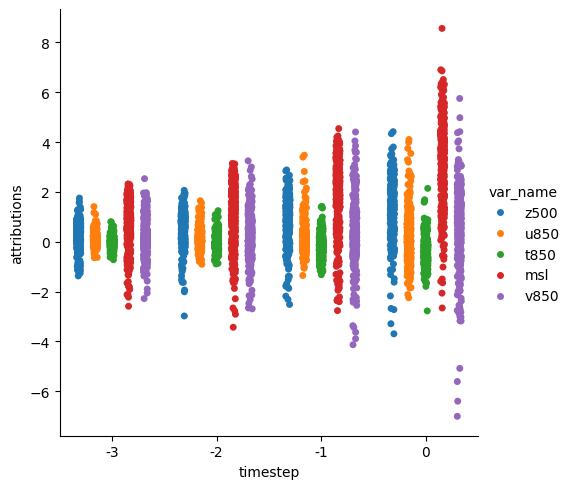

In [ ]:
df_ =ds_attributions.sum(['longitude','latitude']).to_series().rename('attributions').reset_index()
sns.catplot(df_, x='timestep', y='attributions', hue='var_name', dodge=True)

In [42]:
ds_attrs = final_ds
df_features = pd.read_csv("/Data/gfi/users/rogui7909/data/attribute_precip_features/western_norway/features_attributed_to_rain_per_day_WN.csv",index_col=0, parse_dates=True)
ds_precip = xr.open_dataset('/Data/gfi/users/rogui7909/data/ERA5/precipitation/pr_era5_daily_westnorway_1940-2024.nc')

ds_precip = ds_precip.where(ds_precip>1, drop=True)
ds_extr_pr = ds_precip.where(ds_precip>ds_precip.quantile(.9,'time'), drop=True)

df_features_extr = df_features.loc[ds_extr_pr.time.sel(time=slice('1999-10','2012-01')).values]
all_cyclones = df_features_extr.stack().where(df_features_extr.stack().str.startswith('C_')).dropna().str.split('_', expand=True).iloc[:,1]


all_cyclones = all_cyclones.loc[all_cyclones!='F'].reset_index()
# all_cyclones = all_cyclones.loc[all_cyclones.time.isin(ds_attrs.time.values)]
all_cyclones = all_cyclones.set_index('time')[1]
max_time = all_cyclones.reset_index().groupby([1]).time.max()
cyclogenesis = all_cyclones.reset_index().groupby([1]).time.min()
# all_cyclones

In [43]:
import numpy as np

def haversine_np(lon1, lat1, lon2, lat2, radius=6371):
    """
    Compute the Haversine distance between two points or arrays of points using NumPy.

    Parameters:
        lon1, lat1: float or np.ndarray
            Longitude and latitude of the first point(s) in degrees.
        lon2, lat2: float or np.ndarray
            Longitude and latitude of the second point(s) in degrees.
        radius: float
            Radius of the Earth in kilometers (default is 6371 km).

    Returns:
        np.ndarray or float
            Distance in kilometers.
    """
    # Convert degrees to radians
    lon1 = np.radians(lon1)
    lat1 = np.radians(lat1)
    lon2 = np.radians(lon2)
    lat2 = np.radians(lat2)

    # Compute differences
    dlon = lon2 - lon1
    dlat = lat2 - lat1

    # Haversine formula
    a = np.sin(dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return radius * c


def get_cyclones_distance_from_time(time):
    features = df_features.loc[time].iloc[:-2].dropna()
    
    cyclones_list = features.loc[features.str.startswith('C_')].str.split('_',expand=True).iloc[:,1].values.astype(float)
    if len(cyclones_list)==0:
        return
    cycs = xr.open_dataset('/Data/gfi/spengler/kko033/cyclone_clustering/data/all_combined_NH_trcks.nc').to_dataframe()
    cycs['day'] = cycs.date.dt.round('D')

    cycs_extract= cycs.loc[cycs.track_id.isin(cyclones_list)]
    cycs_extract = cycs_extract.loc[cycs_extract.date.round('D')<=pd.to_datetime(time)]
    if len(cycs_extract)==0:
        print('Cyclone filtered out, maybe error')
        return
    grid = xr.zeros_like(ds_attrs.attributions.isel(time=0, var_name=0, timestep=0))#.expand_dims(time=cycs_extract.day.unique())

    lon_center = cycs_extract.set_index('track_id').lon.to_xarray().rename(track_id = 'cyclone_track_id')
    lat_center = cycs_extract.set_index('track_id').lat.to_xarray().rename(track_id = 'cyclone_track_id')
    date = cycs_extract.set_index('track_id').day.to_xarray().rename(track_id = 'cyclone_track_id')
    track_id = cycs_extract.set_index('track_id').to_xarray().rename(track_id = 'cyclone_track_id').cyclone_track_id

    distances_from_cyclone = haversine_np(lon_center,lat_center,grid+grid.longitude, grid+grid.latitude)
    distances_from_cyclone = distances_from_cyclone.where(distances_from_cyclone == distances_from_cyclone.groupby(date).min())
    distances_from_cyclone = distances_from_cyclone.assign_coords(day=np.arange(-distances_from_cyclone.day.size+1,1)).drop_vars('timestep').rename(day='timestep')
    return distances_from_cyclone.min('cyclone_track_id')

In [ ]:
df_feature_attrs = df_features_extr.loc[df_features_extr.index.isin(ds_attrs.time.values)]
all_ds_features = []
for time in tqdm(df_feature_attrs.index.round('D')[:]):
    features = dict()
    try:
        distance_from_cyclone = get_cyclones_distance_from_time(time)
        if distance_from_cyclone is not None:
            features['cyclones']= distance_from_cyclone

    except:
        print(f"{time} failed on cyclones")
    if features != dict():
        ds_features = xr.Dataset(features).to_array('feature').assign_coords(time=time)
        all_ds_features.append(ds_features)
    
# ds_features_attrs = xr.concat(all_ds_features, dim='time', coords='minimal')
ds_features_attrs = xr.concat([d.expand_dims(time=1) for d in all_ds_features], dim='time').squeeze().isel(class_id=0, drop=True).sel(timestep=[-3,-2,-1,0])


  0%|          | 1/329 [00:03<16:32,  3.02s/it]

1999-10-10 00:00:00 failed on cyclones


  1%|          | 2/329 [00:04<10:48,  1.98s/it]

1999-10-11 00:00:00 failed on cyclones


  1%|          | 3/329 [00:05<08:52,  1.63s/it]

...

2002-03-05 00:00:00 failed on cyclones


 20%|██        | 66/329 [01:12<04:22,  1.00it/s]

2002-03-08 00:00:00 failed on cyclones


 20%|██        | 67/329 [01:13<04:34,  1.05s/it]

2002-03-09 00:00:00 failed on cyclones


In [ ]:
attrs = ds_attrs.sel(time=ds_features_attrs.time.values).assign_coords(timestep=[-3,-2,-1,0]).attributions
distances = ds_features_attrs.sel(timestep=slice(-3,0))
ds_ = xr.Dataset(dict(attributions=attrs, distances=distances))

ds_

<xarray.Dataset> Size: 1GB
Dimensions:       (class_id: 3, var_name: 5, latitude: 90, longitude: 182,
                   time: 262, timestep: 4)
Coordinates:
  * class_id      (class_id) <U10 120B 'no-extreme' 'grey-zone' 'extreme'
  * var_name      (var_name) <U4 80B 't850' 'z500' 'v850' 'u850' 'msl'
  * latitude      (latitude) float64 720B 0.0 1.0 2.0 3.0 ... 87.0 88.0 89.0
  * longitude     (longitude) float64 1kB -128.0 -127.0 -126.0 ... 52.0 53.0
  * time          (time) datetime64[ns] 2kB 1999-10-10 1999-10-11 ... 2012-01-10
  * timestep      (timestep) int64 32B -3 -2 -1 0
    feature       <U8 32B 'cyclones'
Data variables:
    attributions  (time, class_id, timestep, var_name, latitude, longitude) float32 1GB ...
    distances     (time, latitude, longitude, timestep) float64 137MB nan ......

In [ ]:
final_ds

<xarray.DataArray (dim_0: 4, dim_1: 3)> Size: 48B
array([[ 4.8852530e+00,  4.1233915e-01, -6.7410097e-03],
       [ 3.6344326e+00,  2.1675253e-01, -3.4097927e-03],
       [ 3.0997040e+00, -6.3492954e-03, -1.8598188e-03],
       [ 2.9979205e+00, -7.0555676e-03,  5.1348574e-02]], dtype=float32)
Dimensions without coordinates: dim_0, dim_1

<Axes: >

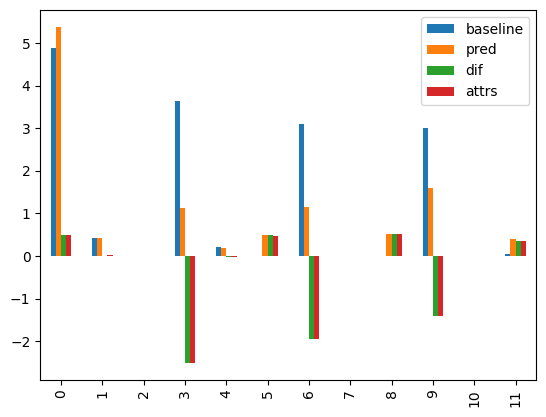

In [ ]:

tensor = torch.Tensor(ds_test_extract.features.isel(time=[0]).values).repeat(12, 1, 1, 1)
attr = method.attribute(tensor,baselines=0, target=[k for k in range(12)])

with torch.no_grad():
    baseline = lightning_model.model(tensor[:1]*0)
    y = lightning_model.model(tensor[:1])
    diff = y-baseline

baseline_da = xr.DataArray(baseline.view(4,3), dims=['timestep','class_id'], coords=dict(timestep=np.arange(-3,1), class_id=['no-extreme','grey-zone','extreme']))
summed_attr = attr.sum(axis=[1,2,3])
# plt.scatter(y, summed_attr)

# print(summed_attr)
df = pd.DataFrame(dict(baseline=baseline.squeeze(), pred=y.squeeze(), dif = diff.squeeze(), attrs=summed_attr), index=np.arange(0,12))
df.plot.bar()
# tensor_in = torch.Tensor(ds_test_extract.features.values).requires_grad_()

In [ ]:
timesteps = np.arange(-steps+1,1)
ds_attributions = xr.concat(all_multi_attrs, dim='time').assign_coords(timestep=timesteps)

In [ ]:
ds_prediction

<xarray.Dataset> Size: 332kB
Dimensions:        (time_of_event: 4605, timestep: 4)
Coordinates:
  * time_of_event  (time_of_event) datetime64[ns] 37kB 1999-07-05 ... 2012-02-11
  * timestep       (timestep) int64 32B -3 -2 -1 0
Data variables:
    target         (time_of_event, timestep) int64 147kB 0 0 0 0 0 ... 0 0 0 0 0
    prediction     (time_of_event, timestep) int64 147kB 0 0 0 0 0 ... 0 0 0 0 0

,time,class_id,timestep,attributions
0,1999-07-05,no-extreme,-3,4.260164
1,1999-07-05,no-extreme,-2,3.221076
2,1999-07-05,no-extreme,-1,1.699771
3,1999-07-05,no-extreme,0,0.136553
4,1999-07-05,grey-zone,-3,0.415667
...,...,...,...,...
8431,2001-06-06,grey-zone,0,0.453159
8432,2001-06-06,extreme,-3,0.550850
8433,2001-06-06,extreme,-2,0.508065
8434,2001-06-06,extreme,-1,0.473887


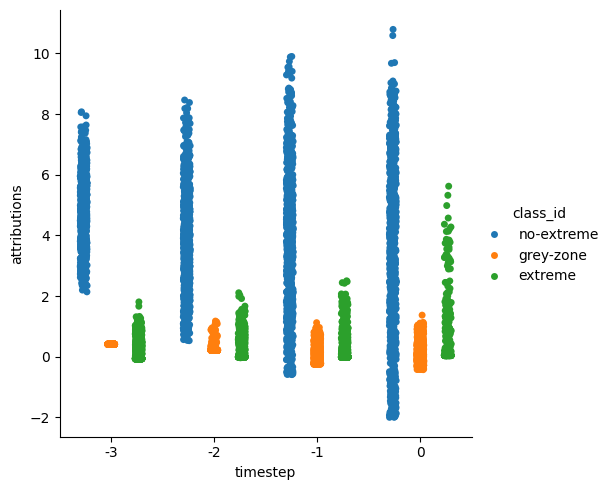

In [ ]:
df_ = (ds_attributions.sum(['longitude','latitude','var_name'])+baseline_da).to_series().rename('attributions').reset_index()

sns.catplot(df_, x='timestep', y='attributions', hue='class_id', dodge=True)
df_
# probas[0]

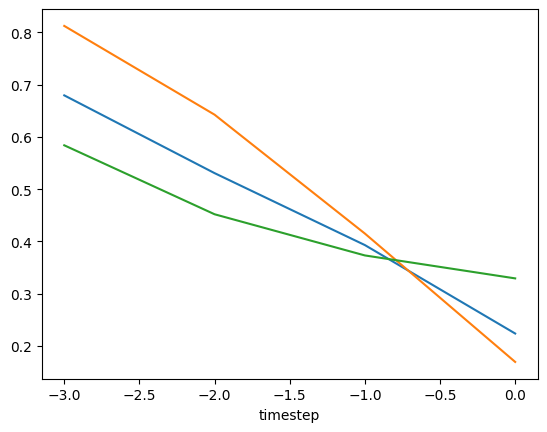

In [ ]:
TP = ((ds_prediction.target==ds_prediction.prediction) & (ds_prediction.target==2)).sum('time_of_event')
recall = TP/( (ds_prediction.target==2)).sum('time_of_event')
precision = TP/( (ds_prediction.prediction==2)).sum('time_of_event')
F1 = 2*recall*precision/(recall+precision)

F1.plot(label='F1')
recall.plot(label='recall')
precision.plot(label='precision')

In [ ]:
all_predictions = pd.DataFrame(dict(predictions=series_predictions, targets=series_targets)).reset_index()
all_predictions.columns = ['time_of_prediction','timestep','prediction','target']
all_predictions['time_of_event'] = all_predictions.time_of_prediction + all_predictions.timestep*pd.Timedelta(1,'D')
valid_times = all_predictions.groupby("time_of_event").target.count().reset_index().query(f"target=={dataloader.config['num_timesteps_predicted']}").time_of_event # Only four predictions
all_predictions = all_predictions.loc[all_predictions.time_of_event.isin(valid_times)]

match samples_to_attribute:
    case 'TP':
        time_of_attributions = all_predictions.query("(prediction==target) & (target==2)").groupby('time_of_event').time_of_prediction.count().reset_index().query("time_of_prediction==4").time_of_event.values
    case 'all-extr':
        time_of_attributions = all_predictions.query(" target==2").time_of_event.unique()
    case 'all':
        time_of_attributions = all_predictions.time_of_event.unique()
    case _:
        print("Invalid selection of attributions")


time        timestep
1999-07-02  0           0
            1           0
            2           0
            3           0
1999-07-03  0           0
                       ..
2012-02-10  3           0
2012-02-11  0           0
            1           0
            2           0
            3           0
Name: predictions, Length: 18432, dtype: int64

In [ ]:


all_targets = []
all_probas = []
for batch in tqdm(dataloader.val_loader):
    x, y = batch
    lightning_model.eval()
    with torch.no_grad():
        all_probas.append(lightning_model(x))
    all_targets.append(y)
probas = torch.cat(all_probas).view(-1, dataloader.config['num_timesteps_predicted'], dataloader.config['prediction_per_timestep'])
targets = torch.cat(all_targets).cpu().numpy()
preds = torch.argmax(probas, dim=2).cpu().numpy() 
probas = probas.cpu().numpy()

ds_aligned = dataloader.ds_val.isel(time=range(targets.shape[0]))
preds_da = xr.DataArray(preds, dims=['time','timestep'], coords =ds_aligned.targets.coords)
ds_aligned ['predictions'] = preds_da

series_targets = ds_aligned.targets.to_series()
series_predictions = ds_aligned.predictions.to_series()

Seed set to 42


Data ready:
    Image size: 16380 (182x90)
    Input variables: t850, z500, v850, u850, msl
    21732 samples in train
    4657 samples in validation
    4658 samples in test
    4 Predicted timesteps for future rainfall
    Prediction type: three_classes_grey_zone
    What quantile is considered extreme: 90th of rainy days


100%|██████████| 9/9 [00:16<00:00,  1.83s/it]


tensor([[0.5317, 0.3497, 0.1528, 0.0844, 0.2325, 0.2838, 0.1788, 0.2089, 0.3019,
         0.2051, 0.2089, 0.2615],
        [0.1398, 0.4226, 0.2928, 0.4086, 0.2099, 0.1825, 0.2608, 0.1838, 0.2141,
         0.1908, 0.1836, 0.3106],
        [0.8666, 0.2767, 0.2485, 0.0949, 0.2421, 0.2492, 0.0181, 0.2404, 0.2507,
         0.0204, 0.2409, 0.2516],
        [0.8182, 0.3351, 0.2480, 0.1728, 0.3513, 0.2492, 0.0078, 0.1567, 0.2509,
         0.0011, 0.1568, 0.2519],
        [0.6940, 0.4322, 0.2314, 0.2820, 0.2072, 0.2321, 0.0143, 0.1804, 0.2359,
         0.0097, 0.1802, 0.3005],
        [0.9772, 0.2672, 0.2415, 0.0149, 0.2512, 0.2436, 0.0038, 0.2405, 0.2448,
         0.0041, 0.2411, 0.2700],
        [0.8614, 0.3492, 0.2390, 0.1253, 0.2748, 0.2410, 0.0104, 0.1879, 0.2428,
         0.0028, 0.1881, 0.2771],
        [0.5234, 0.4140, 0.2486, 0.3402, 0.3575, 0.2500, 0.1032, 0.1143, 0.2502,
         0.0332, 0.1142, 0.2511],
        [0.4340, 0.3235, 0.2497, 0.4017, 0.3155, 0.2495, 0.1064, 0.1805, 0.2500,

In [ ]:
all_predictions = pd.DataFrame(dict(predictions=series_predictions, targets=series_targets)).reset_index()
all_predictions.columns = ['time_of_prediction','timestep','prediction','target']
all_predictions['time_of_event'] = all_predictions.time_of_prediction + all_predictions.timestep*pd.Timedelta(1,'D')
valid_times = all_predictions.groupby("time_of_event").target.count().reset_index().query(f"target=={dataloader.config['num_timesteps_predicted']}").time_of_event # Only four predictions
all_predictions = all_predictions.loc[all_predictions.time_of_event.isin(valid_times)]

match samples_to_attribute:
    case 'TP':
        time_of_attributions = all_predictions.query("(prediction==target) & (target==2)").groupby('time_of_event').time_of_prediction.count().reset_index().query("time_of_prediction==4").time_of_event.values
    case 'all-extr':
        time_of_attributions = all_predictions.query(" target==2").time_of_event.unique()
    case 'all':
        time_of_attributions = all_predictions.time_of_event.unique()
    case _:
        print("Invalid selection of attributions")


steps = dataloader.config['num_timesteps_predicted']
predictions_attributions = all_predictions.loc[all_predictions.time_of_event.isin(time_of_attributions)].sort_values(['time_of_event','timestep'], ascending=[True, False])
start_times = predictions_attributions.query(f"timestep=={steps-1}").time_of_prediction.dt.strftime("%Y-%m-%d %H:%M:%S").values
end_times = predictions_attributions.query("timestep==0").time_of_prediction.dt.strftime("%Y-%m-%d %H:%M:%S").values
method = IntegratedGradients(lightning_model.model)
all_multi_attrs = []
all_multi_sens = []
for k in tqdm(range(len(start_times))):
    start = start_times[k]
    end = end_times[k]
    ds_test_extract =  ds_aligned.sel(time=slice(start ,end))
    tensor_in = torch.Tensor(ds_test_extract.features.values).requires_grad_()
    attrs_0 = method.attribute(tensor_in, baselines=torch.Tensor([0]),target=[3*(steps-k)-3 for k in range(steps)]) 
    attrs_1 = method.attribute(tensor_in, baselines=torch.Tensor([0]),target=[3*(steps-k)-2 for k in range(steps)]) 
    attrs_2 = method.attribute(tensor_in, baselines=torch.Tensor([0]),target=[3*(steps-k)-1 for k in range(steps)]) 
    attrs = torch.stack([attrs_0,attrs_1,attrs_2])
    da_attrs = xr.DataArray(attrs.detach(), dims = ['class_id','timestep','var_name','latitude','longitude'], 
                                coords= dict(class_id=['no-extreme','grey-zone','extreme'],timestep=np.arange(1,steps+1),var_name=ds_test_extract.var_name, latitude=ds_test_extract.latitude, longitude=ds_test_extract.longitude))
#     # print(start,end)
#     ds_test_extract =  ds_aligned.sel(time=slice(start ,end))
#     tensor_in = torch.Tensor(ds_test_extract.features.values)
#     tensor_out = torch.Tensor(ds_test_extract.targets.values)
#     attrs = method.attribute(tensor_in, baselines=torch.Tensor([0]),target=[3*(steps-k)-1 for k in range(steps)]) 
#     da_attrs = xr.DataArray(attrs, dims = ['timestep','var_name','latitude','longitude'], 
#                             coords= dict(timestep=np.arange(1,steps+1),var_name=ds_test_extract.var_name, latitude=ds_test_extract.latitude, longitude=ds_test_extract.longitude))
    all_multi_attrs.append(da_attrs.assign_coords(time=time_of_attributions[k]))
    sens = da_attrs/ds_test_extract.features.rename(time='timestep').assign_coords(timestep=da_attrs.timestep)
    all_multi_sens.append(sens.assign_coords(time=time_of_attributions[k]))

100%|██████████| 330/330 [01:49<00:00,  3.01it/s]


In [ ]:
timesteps = np.arange(-steps+1,1)
ds_attributions = xr.concat(all_multi_attrs, dim='time').assign_coords(timestep=timesteps)
ds_sens = xr.concat(all_multi_sens, dim='time').assign_coords(timestep=timesteps)
ds_predictions_attributions = predictions_attributions.set_index(['time_of_event','timestep'])[['prediction','target']].to_xarray().rename(time_of_event='time')
ds_predictions_attributions = ds_predictions_attributions.assign_coords(timestep=-ds_predictions_attributions.timestep).sortby('timestep')
final_ds = xr.merge([xr.Dataset(dict(attributions = ds_attributions, sensitivity=ds_sens)), ds_predictions_attributions])
final_ds['rain'] = ds_aligned.rain.isel(timestep=0, drop=True)
final_ds.to_netcdf(f"/Data/gfi/users/rogui7909/data/NN_outputs/attributions/{run_id}_attributions_{samples_to_attribute}_all-classes.nc")

In [ ]:
final_ds = xr.open_dataset(f"/Data/gfi/users/rogui7909/data/NN_outputs/attributions/{run_id}_attributions_{samples_to_attribute}_all-classes.nc")

<Axes: xlabel='rain', ylabel='Count'>

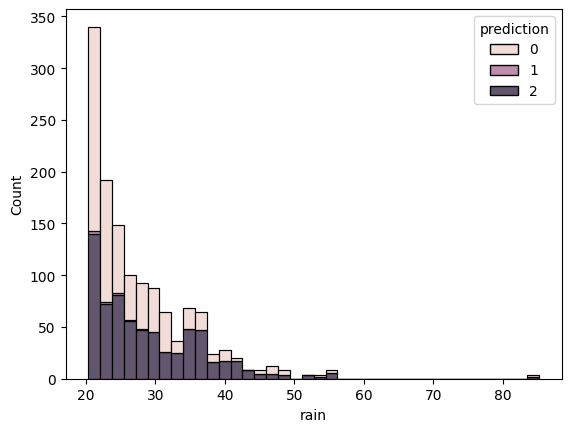

In [ ]:
df_ = final_ds[['rain','prediction']].to_dataframe()

sns.histplot(df_, x='rain', hue='prediction', multiple='stack')

In [ ]:
ds_attrs = final_ds
df_features = pd.read_csv("/Data/gfi/users/rogui7909/data/attribute_precip_features/western_norway/features_attributed_to_rain_per_day_WN.csv",index_col=0, parse_dates=True)
ds_precip = xr.open_dataset('/Data/gfi/users/rogui7909/data/ERA5/precipitation/pr_era5_daily_westnorway_1940-2024.nc')

ds_precip = ds_precip.where(ds_precip>1, drop=True)
ds_extr_pr = ds_precip.where(ds_precip>ds_precip.quantile(.9,'time'), drop=True)

df_features_extr = df_features.loc[ds_extr_pr.time.sel(time=slice('1999-10','2012-01')).values]
all_cyclones = df_features_extr.stack().where(df_features_extr.stack().str.startswith('C_')).dropna().str.split('_', expand=True).iloc[:,1]


all_cyclones = all_cyclones.loc[all_cyclones!='F'].reset_index()
# all_cyclones = all_cyclones.loc[all_cyclones.time.isin(ds_attrs.time.values)]
all_cyclones = all_cyclones.set_index('time')[1]
max_time = all_cyclones.reset_index().groupby([1]).time.max()
cyclogenesis = all_cyclones.reset_index().groupby([1]).time.min()
# all_cyclones

In [ ]:
import numpy as np

def haversine_np(lon1, lat1, lon2, lat2, radius=6371):
    """
    Compute the Haversine distance between two points or arrays of points using NumPy.

    Parameters:
        lon1, lat1: float or np.ndarray
            Longitude and latitude of the first point(s) in degrees.
        lon2, lat2: float or np.ndarray
            Longitude and latitude of the second point(s) in degrees.
        radius: float
            Radius of the Earth in kilometers (default is 6371 km).

    Returns:
        np.ndarray or float
            Distance in kilometers.
    """
    # Convert degrees to radians
    lon1 = np.radians(lon1)
    lat1 = np.radians(lat1)
    lon2 = np.radians(lon2)
    lat2 = np.radians(lat2)

    # Compute differences
    dlon = lon2 - lon1
    dlat = lat2 - lat1

    # Haversine formula
    a = np.sin(dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return radius * c


def get_cyclones_distance_from_time(time):
    features = df_features.loc[time].iloc[:-2].dropna()
    
    cyclones_list = features.loc[features.str.startswith('C_')].str.split('_',expand=True).iloc[:,1].values.astype(float)
    if len(cyclones_list)==0:
        return
    cycs = xr.open_dataset('/Data/gfi/spengler/kko033/cyclone_clustering/data/all_combined_NH_trcks.nc').to_dataframe()
    cycs['day'] = cycs.date.dt.round('D')

    cycs_extract= cycs.loc[cycs.track_id.isin(cyclones_list)]
    cycs_extract = cycs_extract.loc[cycs_extract.date.round('D')<=pd.to_datetime(time)]
    if len(cycs_extract)==0:
        print('Cyclone filtered out, maybe error')
        return
    grid = xr.zeros_like(ds_attrs.attributions.isel(time=0, var_name=0, timestep=0))#.expand_dims(time=cycs_extract.day.unique())

    lon_center = cycs_extract.set_index('track_id').lon.to_xarray().rename(track_id = 'cyclone_track_id')
    lat_center = cycs_extract.set_index('track_id').lat.to_xarray().rename(track_id = 'cyclone_track_id')
    date = cycs_extract.set_index('track_id').day.to_xarray().rename(track_id = 'cyclone_track_id')
    track_id = cycs_extract.set_index('track_id').to_xarray().rename(track_id = 'cyclone_track_id').cyclone_track_id

    distances_from_cyclone = haversine_np(lon_center,lat_center,grid+grid.longitude, grid+grid.latitude)
    distances_from_cyclone = distances_from_cyclone.where(distances_from_cyclone == distances_from_cyclone.groupby(date).min())
    distances_from_cyclone = distances_from_cyclone.assign_coords(day=np.arange(-distances_from_cyclone.day.size+1,1)).drop_vars('timestep').rename(day='timestep')
    return distances_from_cyclone.min('cyclone_track_id')

In [ ]:
df_feature_attrs = df_features_extr.loc[df_features_extr.index.isin(ds_attrs.time.values)]
all_ds_features = []
for time in tqdm(df_feature_attrs.index.round('D')[:]):
    features = dict()
    try:
        distance_from_cyclone = get_cyclones_distance_from_time(time)
        if distance_from_cyclone is not None:
            features['cyclones']= distance_from_cyclone

    except:
        print(f"{time} failed on cyclones")
    if features != dict():
        ds_features = xr.Dataset(features).to_array('feature').assign_coords(time=time)
        all_ds_features.append(ds_features)
    
# ds_features_attrs = xr.concat(all_ds_features, dim='time', coords='minimal')
ds_features_attrs = xr.concat([d.expand_dims(time=1) for d in all_ds_features], dim='time').squeeze().isel(class_id=0, drop=True).sel(timestep=[-3,-2,-1,0])


  2%|▏         | 6/329 [00:11<09:36,  1.79s/it]

Cyclone filtered out, maybe error
1999-11-24 00:00:00 failed on cyclones


  4%|▎         | 12/329 [00:20<08:49,  1.67s/it]

Cyclone filtered out, maybe error


  6%|▌         | 19/329 [00:31<08:08,  1.58s/it]

...

2011-11-23 00:00:00 failed on cyclones


 99%|█████████▉| 325/329 [07:56<00:07,  1.95s/it]

2011-12-25 00:00:00 failed on cyclones


100%|██████████| 329/329 [08:00<00:00,  1.46s/it]


2012-01-11 00:00:00 failed on cyclones


In [ ]:
attrs = ds_attrs.sel(time=ds_features_attrs.time.values).assign_coords(timestep=[-3,-2,-1,0]).attributions
distances = ds_features_attrs.sel(timestep=slice(-3,0))
ds_ = xr.Dataset(dict(attributions=attrs, distances=distances))

ds_

<xarray.Dataset> Size: 1GB
Dimensions:       (class_id: 3, var_name: 5, latitude: 90, longitude: 182,
                   time: 262, timestep: 4)
Coordinates:
  * class_id      (class_id) <U10 120B 'no-extreme' 'grey-zone' 'extreme'
  * var_name      (var_name) <U4 80B 't850' 'z500' 'v850' 'u850' 'msl'
  * latitude      (latitude) float64 720B 0.0 1.0 2.0 3.0 ... 87.0 88.0 89.0
  * longitude     (longitude) float64 1kB -128.0 -127.0 -126.0 ... 52.0 53.0
  * time          (time) datetime64[ns] 2kB 1999-10-10 1999-10-11 ... 2012-01-10
  * timestep      (timestep) int64 32B -3 -2 -1 0
    feature       <U8 32B 'cyclones'
Data variables:
    attributions  (time, class_id, timestep, var_name, latitude, longitude) float32 1GB ...
    distances     (time, latitude, longitude, timestep) float64 137MB nan ......

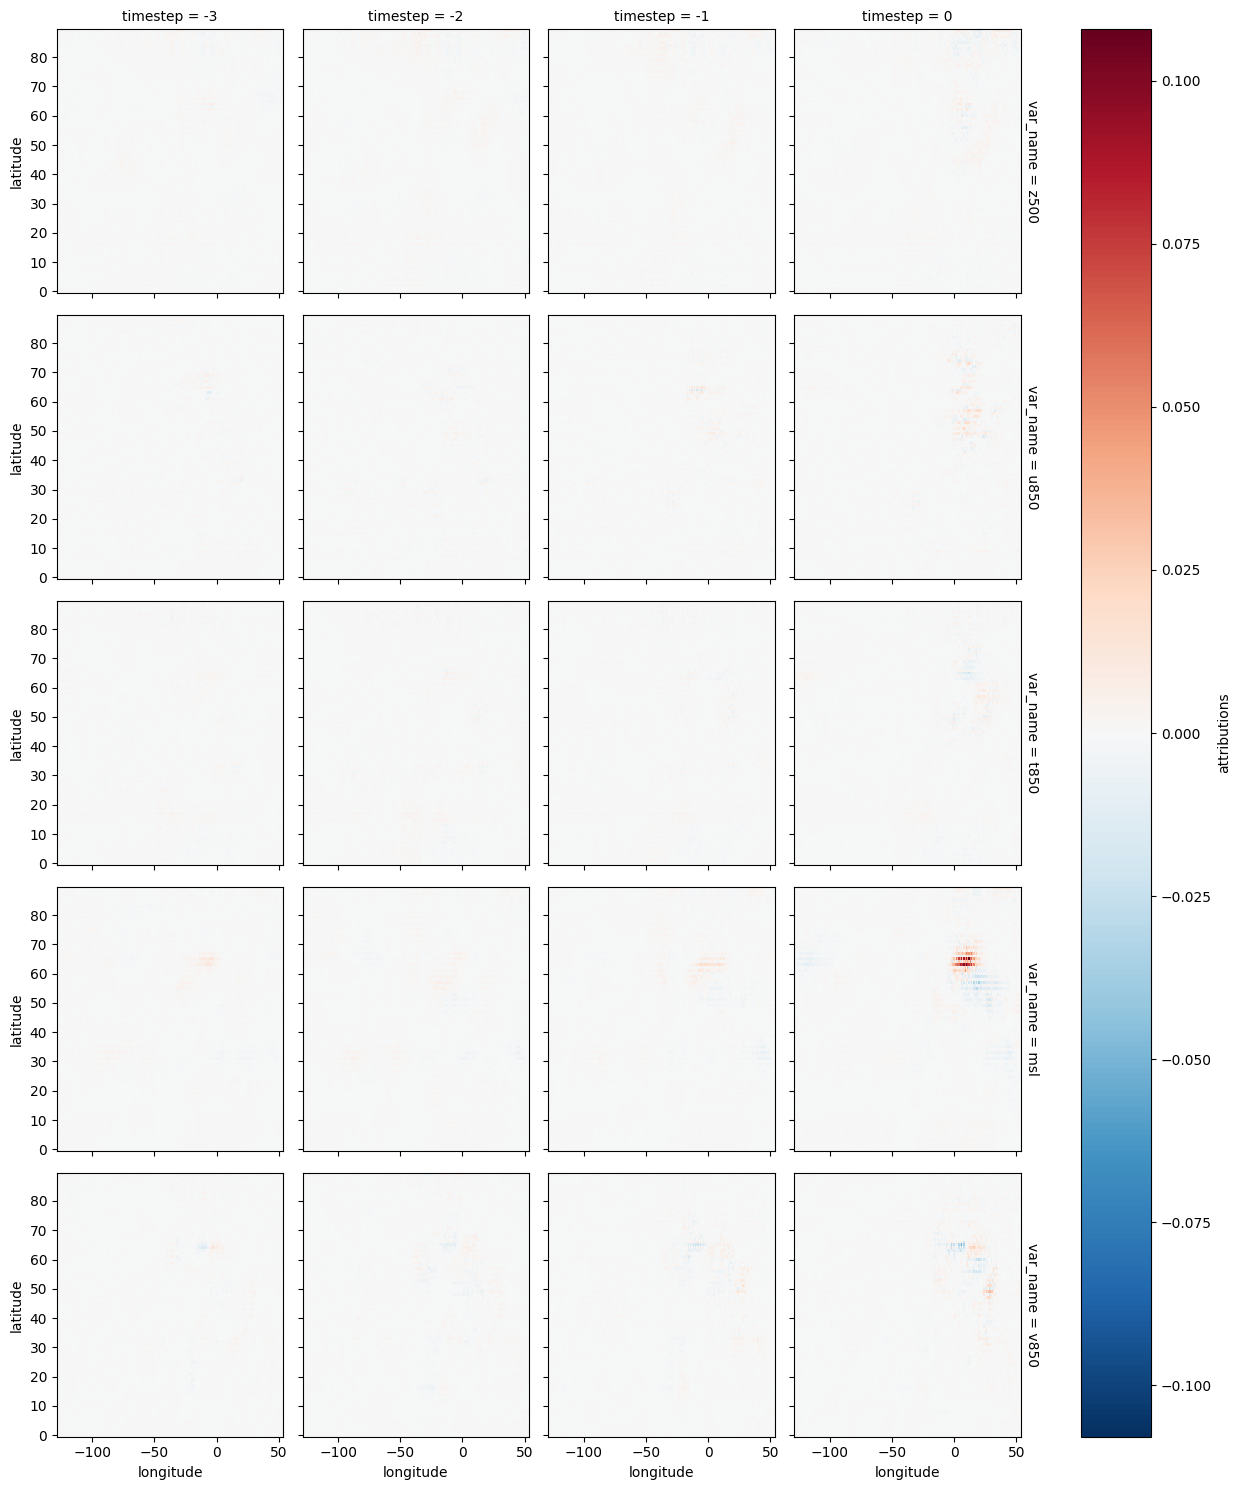

In [38]:
final_ds.attributions.isel(time_of_event=0).plot(col='timestep', row='var_name')

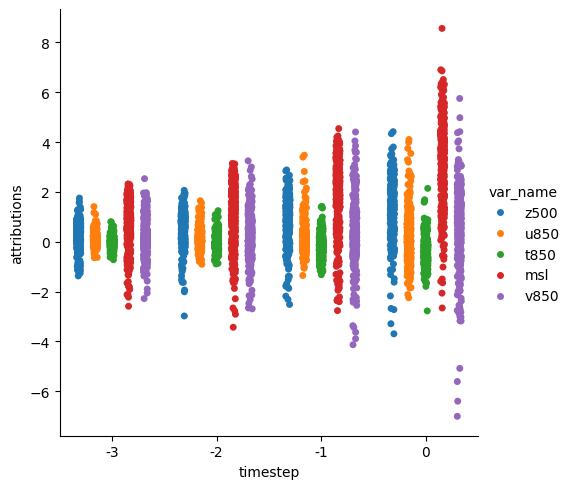

In [41]:
df_ =ds_attributions.sum(['longitude','latitude']).to_series().rename('attributions').reset_index()
sns.catplot(df_, x='timestep', y='attributions', hue='var_name', dodge=True)

In [ ]:
final_ds

<xarray.DataArray (dim_0: 4, dim_1: 3)> Size: 48B
array([[ 4.8852530e+00,  4.1233915e-01, -6.7410097e-03],
       [ 3.6344326e+00,  2.1675253e-01, -3.4097927e-03],
       [ 3.0997040e+00, -6.3492954e-03, -1.8598188e-03],
       [ 2.9979205e+00, -7.0555676e-03,  5.1348574e-02]], dtype=float32)
Dimensions without coordinates: dim_0, dim_1

<Axes: >

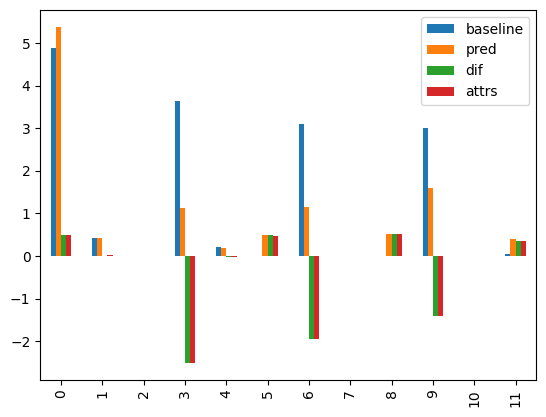

In [99]:

tensor = torch.Tensor(ds_test_extract.features.isel(time=[0]).values).repeat(12, 1, 1, 1)
attr = method.attribute(tensor,baselines=0, target=[k for k in range(12)])

with torch.no_grad():
    baseline = lightning_model.model(tensor[:1]*0)
    y = lightning_model.model(tensor[:1])
    diff = y-baseline

baseline_da = xr.DataArray(baseline.view(4,3), dims=['timestep','class_id'], coords=dict(timestep=np.arange(-3,1), class_id=['no-extreme','grey-zone','extreme']))
summed_attr = attr.sum(axis=[1,2,3])
# plt.scatter(y, summed_attr)

# print(summed_attr)
df = pd.DataFrame(dict(baseline=baseline.squeeze(), pred=y.squeeze(), dif = diff.squeeze(), attrs=summed_attr), index=np.arange(0,12))
df.plot.bar()
# tensor_in = torch.Tensor(ds_test_extract.features.values).requires_grad_()

In [16]:
timesteps = np.arange(-steps+1,1)
ds_attributions = xr.concat(all_multi_attrs, dim='time').assign_coords(timestep=timesteps)

In [22]:
ds_prediction

<xarray.Dataset> Size: 332kB
Dimensions:        (time_of_event: 4605, timestep: 4)
Coordinates:
  * time_of_event  (time_of_event) datetime64[ns] 37kB 1999-07-05 ... 2012-02-11
  * timestep       (timestep) int64 32B -3 -2 -1 0
Data variables:
    target         (time_of_event, timestep) int64 147kB 0 0 0 0 0 ... 0 0 0 0 0
    prediction     (time_of_event, timestep) int64 147kB 0 0 0 0 0 ... 0 0 0 0 0

,time,class_id,timestep,attributions
0,1999-07-05,no-extreme,-3,4.260164
1,1999-07-05,no-extreme,-2,3.221076
2,1999-07-05,no-extreme,-1,1.699771
3,1999-07-05,no-extreme,0,0.136553
4,1999-07-05,grey-zone,-3,0.415667
...,...,...,...,...
8431,2001-06-06,grey-zone,0,0.453159
8432,2001-06-06,extreme,-3,0.550850
8433,2001-06-06,extreme,-2,0.508065
8434,2001-06-06,extreme,-1,0.473887


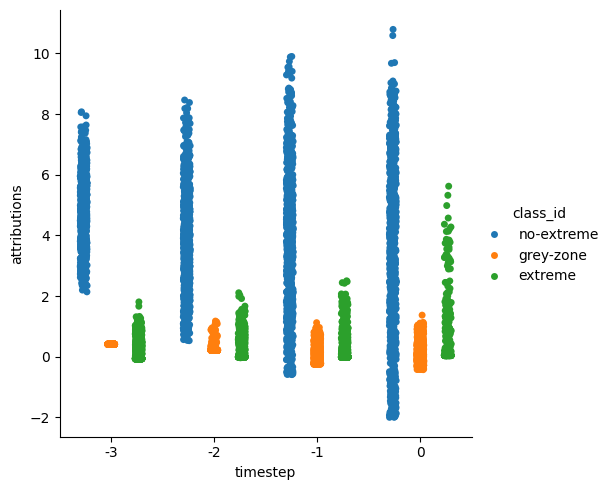

In [110]:
df_ = (ds_attributions.sum(['longitude','latitude','var_name'])+baseline_da).to_series().rename('attributions').reset_index()

sns.catplot(df_, x='timestep', y='attributions', hue='class_id', dodge=True)
df_
# probas[0]

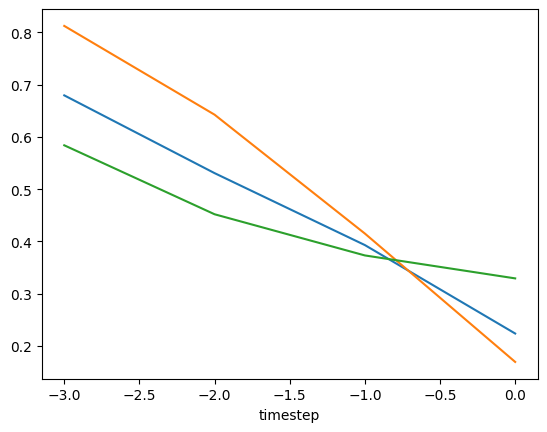

In [36]:
TP = ((ds_prediction.target==ds_prediction.prediction) & (ds_prediction.target==2)).sum('time_of_event')
recall = TP/( (ds_prediction.target==2)).sum('time_of_event')
precision = TP/( (ds_prediction.prediction==2)).sum('time_of_event')
F1 = 2*recall*precision/(recall+precision)

F1.plot(label='F1')
recall.plot(label='recall')
precision.plot(label='precision')

In [ ]:
all_predictions = pd.DataFrame(dict(predictions=series_predictions, targets=series_targets)).reset_index()
all_predictions.columns = ['time_of_prediction','timestep','prediction','target']
all_predictions['time_of_event'] = all_predictions.time_of_prediction + all_predictions.timestep*pd.Timedelta(1,'D')
valid_times = all_predictions.groupby("time_of_event").target.count().reset_index().query(f"target=={dataloader.config['num_timesteps_predicted']}").time_of_event # Only four predictions
all_predictions = all_predictions.loc[all_predictions.time_of_event.isin(valid_times)]

match samples_to_attribute:
    case 'TP':
        time_of_attributions = all_predictions.query("(prediction==target) & (target==2)").groupby('time_of_event').time_of_prediction.count().reset_index().query("time_of_prediction==4").time_of_event.values
    case 'all-extr':
        time_of_attributions = all_predictions.query(" target==2").time_of_event.unique()
    case 'all':
        time_of_attributions = all_predictions.time_of_event.unique()
    case _:
        print("Invalid selection of attributions")


time        timestep
1999-07-02  0           0
            1           0
            2           0
            3           0
1999-07-03  0           0
                       ..
2012-02-10  3           0
2012-02-11  0           0
            1           0
            2           0
            3           0
Name: predictions, Length: 18432, dtype: int64

In [ ]:


all_targets = []
all_probas = []
for batch in tqdm(dataloader.val_loader):
    x, y = batch
    lightning_model.eval()
    with torch.no_grad():
        all_probas.append(lightning_model(x))
    all_targets.append(y)
probas = torch.cat(all_probas).view(-1, dataloader.config['num_timesteps_predicted'], dataloader.config['prediction_per_timestep'])
targets = torch.cat(all_targets).cpu().numpy()
preds = torch.argmax(probas, dim=2).cpu().numpy() 
probas = probas.cpu().numpy()

ds_aligned = dataloader.ds_val.isel(time=range(targets.shape[0]))
preds_da = xr.DataArray(preds, dims=['time','timestep'], coords =ds_aligned.targets.coords)
ds_aligned ['predictions'] = preds_da

series_targets = ds_aligned.targets.to_series()
series_predictions = ds_aligned.predictions.to_series()

Seed set to 42


Data ready:
    Image size: 16380 (182x90)
    Input variables: t850, z500, v850, u850, msl
    21732 samples in train
    4657 samples in validation
    4658 samples in test
    4 Predicted timesteps for future rainfall
    Prediction type: three_classes_grey_zone
    What quantile is considered extreme: 90th of rainy days


100%|██████████| 9/9 [00:16<00:00,  1.83s/it]


tensor([[0.5317, 0.3497, 0.1528, 0.0844, 0.2325, 0.2838, 0.1788, 0.2089, 0.3019,
         0.2051, 0.2089, 0.2615],
        [0.1398, 0.4226, 0.2928, 0.4086, 0.2099, 0.1825, 0.2608, 0.1838, 0.2141,
         0.1908, 0.1836, 0.3106],
        [0.8666, 0.2767, 0.2485, 0.0949, 0.2421, 0.2492, 0.0181, 0.2404, 0.2507,
         0.0204, 0.2409, 0.2516],
        [0.8182, 0.3351, 0.2480, 0.1728, 0.3513, 0.2492, 0.0078, 0.1567, 0.2509,
         0.0011, 0.1568, 0.2519],
        [0.6940, 0.4322, 0.2314, 0.2820, 0.2072, 0.2321, 0.0143, 0.1804, 0.2359,
         0.0097, 0.1802, 0.3005],
        [0.9772, 0.2672, 0.2415, 0.0149, 0.2512, 0.2436, 0.0038, 0.2405, 0.2448,
         0.0041, 0.2411, 0.2700],
        [0.8614, 0.3492, 0.2390, 0.1253, 0.2748, 0.2410, 0.0104, 0.1879, 0.2428,
         0.0028, 0.1881, 0.2771],
        [0.5234, 0.4140, 0.2486, 0.3402, 0.3575, 0.2500, 0.1032, 0.1143, 0.2502,
         0.0332, 0.1142, 0.2511],
        [0.4340, 0.3235, 0.2497, 0.4017, 0.3155, 0.2495, 0.1064, 0.1805, 0.2500,

In [ ]:
all_predictions = pd.DataFrame(dict(predictions=series_predictions, targets=series_targets)).reset_index()
all_predictions.columns = ['time_of_prediction','timestep','prediction','target']
all_predictions['time_of_event'] = all_predictions.time_of_prediction + all_predictions.timestep*pd.Timedelta(1,'D')
valid_times = all_predictions.groupby("time_of_event").target.count().reset_index().query(f"target=={dataloader.config['num_timesteps_predicted']}").time_of_event # Only four predictions
all_predictions = all_predictions.loc[all_predictions.time_of_event.isin(valid_times)]

match samples_to_attribute:
    case 'TP':
        time_of_attributions = all_predictions.query("(prediction==target) & (target==2)").groupby('time_of_event').time_of_prediction.count().reset_index().query("time_of_prediction==4").time_of_event.values
    case 'all-extr':
        time_of_attributions = all_predictions.query(" target==2").time_of_event.unique()
    case 'all':
        time_of_attributions = all_predictions.time_of_event.unique()
    case _:
        print("Invalid selection of attributions")


steps = dataloader.config['num_timesteps_predicted']
predictions_attributions = all_predictions.loc[all_predictions.time_of_event.isin(time_of_attributions)].sort_values(['time_of_event','timestep'], ascending=[True, False])
start_times = predictions_attributions.query(f"timestep=={steps-1}").time_of_prediction.dt.strftime("%Y-%m-%d %H:%M:%S").values
end_times = predictions_attributions.query("timestep==0").time_of_prediction.dt.strftime("%Y-%m-%d %H:%M:%S").values
method = IntegratedGradients(lightning_model.model)
all_multi_attrs = []
all_multi_sens = []
for k in tqdm(range(len(start_times))):
    start = start_times[k]
    end = end_times[k]
    ds_test_extract =  ds_aligned.sel(time=slice(start ,end))
    tensor_in = torch.Tensor(ds_test_extract.features.values).requires_grad_()
    attrs_0 = method.attribute(tensor_in, baselines=torch.Tensor([0]),target=[3*(steps-k)-3 for k in range(steps)]) 
    attrs_1 = method.attribute(tensor_in, baselines=torch.Tensor([0]),target=[3*(steps-k)-2 for k in range(steps)]) 
    attrs_2 = method.attribute(tensor_in, baselines=torch.Tensor([0]),target=[3*(steps-k)-1 for k in range(steps)]) 
    attrs = torch.stack([attrs_0,attrs_1,attrs_2])
    da_attrs = xr.DataArray(attrs.detach(), dims = ['class_id','timestep','var_name','latitude','longitude'], 
                                coords= dict(class_id=['no-extreme','grey-zone','extreme'],timestep=np.arange(1,steps+1),var_name=ds_test_extract.var_name, latitude=ds_test_extract.latitude, longitude=ds_test_extract.longitude))
#     # print(start,end)
#     ds_test_extract =  ds_aligned.sel(time=slice(start ,end))
#     tensor_in = torch.Tensor(ds_test_extract.features.values)
#     tensor_out = torch.Tensor(ds_test_extract.targets.values)
#     attrs = method.attribute(tensor_in, baselines=torch.Tensor([0]),target=[3*(steps-k)-1 for k in range(steps)]) 
#     da_attrs = xr.DataArray(attrs, dims = ['timestep','var_name','latitude','longitude'], 
#                             coords= dict(timestep=np.arange(1,steps+1),var_name=ds_test_extract.var_name, latitude=ds_test_extract.latitude, longitude=ds_test_extract.longitude))
    all_multi_attrs.append(da_attrs.assign_coords(time=time_of_attributions[k]))
    sens = da_attrs/ds_test_extract.features.rename(time='timestep').assign_coords(timestep=da_attrs.timestep)
    all_multi_sens.append(sens.assign_coords(time=time_of_attributions[k]))

100%|██████████| 330/330 [01:49<00:00,  3.01it/s]


In [ ]:
timesteps = np.arange(-steps+1,1)
ds_attributions = xr.concat(all_multi_attrs, dim='time').assign_coords(timestep=timesteps)
ds_sens = xr.concat(all_multi_sens, dim='time').assign_coords(timestep=timesteps)
ds_predictions_attributions = predictions_attributions.set_index(['time_of_event','timestep'])[['prediction','target']].to_xarray().rename(time_of_event='time')
ds_predictions_attributions = ds_predictions_attributions.assign_coords(timestep=-ds_predictions_attributions.timestep).sortby('timestep')
final_ds = xr.merge([xr.Dataset(dict(attributions = ds_attributions, sensitivity=ds_sens)), ds_predictions_attributions])
final_ds['rain'] = ds_aligned.rain.isel(timestep=0, drop=True)
final_ds.to_netcdf(f"/Data/gfi/users/rogui7909/data/NN_outputs/attributions/{run_id}_attributions_{samples_to_attribute}_all-classes.nc")

In [3]:
final_ds = xr.open_dataset(f"/Data/gfi/users/rogui7909/data/NN_outputs/attributions/{run_id}_attributions_{samples_to_attribute}_all-classes.nc")

<Axes: xlabel='rain', ylabel='Count'>

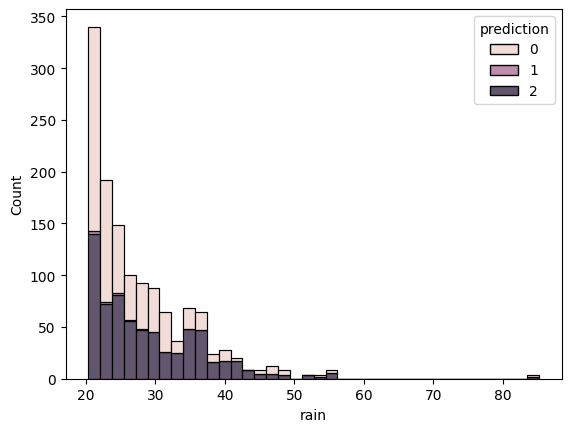

In [169]:
df_ = final_ds[['rain','prediction']].to_dataframe()

sns.histplot(df_, x='rain', hue='prediction', multiple='stack')

In [6]:
ds_attrs = final_ds
df_features = pd.read_csv("/Data/gfi/users/rogui7909/data/attribute_precip_features/western_norway/features_attributed_to_rain_per_day_WN.csv",index_col=0, parse_dates=True)
ds_precip = xr.open_dataset('/Data/gfi/users/rogui7909/data/ERA5/precipitation/pr_era5_daily_westnorway_1940-2024.nc')

ds_precip = ds_precip.where(ds_precip>1, drop=True)
ds_extr_pr = ds_precip.where(ds_precip>ds_precip.quantile(.9,'time'), drop=True)

df_features_extr = df_features.loc[ds_extr_pr.time.sel(time=slice('1999-10','2012-01')).values]
all_cyclones = df_features_extr.stack().where(df_features_extr.stack().str.startswith('C_')).dropna().str.split('_', expand=True).iloc[:,1]


all_cyclones = all_cyclones.loc[all_cyclones!='F'].reset_index()
# all_cyclones = all_cyclones.loc[all_cyclones.time.isin(ds_attrs.time.values)]
all_cyclones = all_cyclones.set_index('time')[1]
max_time = all_cyclones.reset_index().groupby([1]).time.max()
cyclogenesis = all_cyclones.reset_index().groupby([1]).time.min()
# all_cyclones

In [8]:
import numpy as np

def haversine_np(lon1, lat1, lon2, lat2, radius=6371):
    """
    Compute the Haversine distance between two points or arrays of points using NumPy.

    Parameters:
        lon1, lat1: float or np.ndarray
            Longitude and latitude of the first point(s) in degrees.
        lon2, lat2: float or np.ndarray
            Longitude and latitude of the second point(s) in degrees.
        radius: float
            Radius of the Earth in kilometers (default is 6371 km).

    Returns:
        np.ndarray or float
            Distance in kilometers.
    """
    # Convert degrees to radians
    lon1 = np.radians(lon1)
    lat1 = np.radians(lat1)
    lon2 = np.radians(lon2)
    lat2 = np.radians(lat2)

    # Compute differences
    dlon = lon2 - lon1
    dlat = lat2 - lat1

    # Haversine formula
    a = np.sin(dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return radius * c


def get_cyclones_distance_from_time(time):
    features = df_features.loc[time].iloc[:-2].dropna()
    
    cyclones_list = features.loc[features.str.startswith('C_')].str.split('_',expand=True).iloc[:,1].values.astype(float)
    if len(cyclones_list)==0:
        return
    cycs = xr.open_dataset('/Data/gfi/spengler/kko033/cyclone_clustering/data/all_combined_NH_trcks.nc').to_dataframe()
    cycs['day'] = cycs.date.dt.round('D')

    cycs_extract= cycs.loc[cycs.track_id.isin(cyclones_list)]
    cycs_extract = cycs_extract.loc[cycs_extract.date.round('D')<=pd.to_datetime(time)]
    if len(cycs_extract)==0:
        print('Cyclone filtered out, maybe error')
        return
    grid = xr.zeros_like(ds_attrs.attributions.isel(time=0, var_name=0, timestep=0))#.expand_dims(time=cycs_extract.day.unique())

    lon_center = cycs_extract.set_index('track_id').lon.to_xarray().rename(track_id = 'cyclone_track_id')
    lat_center = cycs_extract.set_index('track_id').lat.to_xarray().rename(track_id = 'cyclone_track_id')
    date = cycs_extract.set_index('track_id').day.to_xarray().rename(track_id = 'cyclone_track_id')
    track_id = cycs_extract.set_index('track_id').to_xarray().rename(track_id = 'cyclone_track_id').cyclone_track_id

    distances_from_cyclone = haversine_np(lon_center,lat_center,grid+grid.longitude, grid+grid.latitude)
    distances_from_cyclone = distances_from_cyclone.where(distances_from_cyclone == distances_from_cyclone.groupby(date).min())
    distances_from_cyclone = distances_from_cyclone.assign_coords(day=np.arange(-distances_from_cyclone.day.size+1,1)).drop_vars('timestep').rename(day='timestep')
    return distances_from_cyclone.min('cyclone_track_id')

In [ ]:
df_feature_attrs = df_features_extr.loc[df_features_extr.index.isin(ds_attrs.time.values)]
all_ds_features = []
for time in tqdm(df_feature_attrs.index.round('D')[:]):
    features = dict()
    try:
        distance_from_cyclone = get_cyclones_distance_from_time(time)
        if distance_from_cyclone is not None:
            features['cyclones']= distance_from_cyclone

    except:
        print(f"{time} failed on cyclones")
    if features != dict():
        ds_features = xr.Dataset(features).to_array('feature').assign_coords(time=time)
        all_ds_features.append(ds_features)
    
# ds_features_attrs = xr.concat(all_ds_features, dim='time', coords='minimal')
ds_features_attrs = xr.concat([d.expand_dims(time=1) for d in all_ds_features], dim='time').squeeze().isel(class_id=0, drop=True).sel(timestep=[-3,-2,-1,0])


  2%|▏         | 6/329 [00:11<09:36,  1.79s/it]

Cyclone filtered out, maybe error
1999-11-24 00:00:00 failed on cyclones


  4%|▎         | 12/329 [00:20<08:49,  1.67s/it]

Cyclone filtered out, maybe error


  6%|▌         | 19/329 [00:31<08:08,  1.58s/it]

...

2011-11-23 00:00:00 failed on cyclones


 99%|█████████▉| 325/329 [07:56<00:07,  1.95s/it]

2011-12-25 00:00:00 failed on cyclones


100%|██████████| 329/329 [08:00<00:00,  1.46s/it]


2012-01-11 00:00:00 failed on cyclones


In [20]:
attrs = ds_attrs.sel(time=ds_features_attrs.time.values).assign_coords(timestep=[-3,-2,-1,0]).attributions
distances = ds_features_attrs.sel(timestep=slice(-3,0))
ds_ = xr.Dataset(dict(attributions=attrs, distances=distances))

ds_

<xarray.Dataset> Size: 1GB
Dimensions:       (class_id: 3, var_name: 5, latitude: 90, longitude: 182,
                   time: 262, timestep: 4)
Coordinates:
  * class_id      (class_id) <U10 120B 'no-extreme' 'grey-zone' 'extreme'
  * var_name      (var_name) <U4 80B 't850' 'z500' 'v850' 'u850' 'msl'
  * latitude      (latitude) float64 720B 0.0 1.0 2.0 3.0 ... 87.0 88.0 89.0
  * longitude     (longitude) float64 1kB -128.0 -127.0 -126.0 ... 52.0 53.0
  * time          (time) datetime64[ns] 2kB 1999-10-10 1999-10-11 ... 2012-01-10
  * timestep      (timestep) int64 32B -3 -2 -1 0
    feature       <U8 32B 'cyclones'
Data variables:
    attributions  (time, class_id, timestep, var_name, latitude, longitude) float32 1GB ...
    distances     (time, latitude, longitude, timestep) float64 137MB nan ......

<xarray.DataArray 'prediction' (time: 330, timestep: 4)> Size: 1kB
array([[False, False, False, False],
       [False, False, False, False],
       [False, False,  True,  True],
       ...,
       [ True,  True,  True,  True],
       [False,  True,  True,  True],
       [False,  True,  True,  True]])
Coordinates:
  * time      (time) datetime64[ns] 3kB 1999-07-21 1999-10-10 ... 2012-01-11
  * timestep  (timestep) int64 32B -3 -2 -1 0

In [87]:
attrs = ds_attrs.sel(time=ds_features_attrs.time.values).assign_coords(timestep=[-3,-2,-1,0]).attributions
attrs = attrs.where(final_ds.prediction==0)
distances = ds_features_attrs.sel(timestep=slice(-3,0))
ds = xr.Dataset(dict(attributions=attrs, distances=distances))
df_ = ds.to_dataframe().reset_index()
distance_bins= np.arange(0,10001,250)
summed_attrs = df_.groupby(['class_id','timestep','var_name',pd.cut(df_.distances, distance_bins)]).attributions.mean().reset_index()
# df_ = attrs.groupby_bins(groups, bins).sum().to_series().reset_index()
# df_

/tmp/ipykernel_3150175/2978758140.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summed_attrs = df_.groupby(['class_id','timestep','var_name',pd.cut(df_.distances, distance_bins)]).attributions.mean().reset_index()


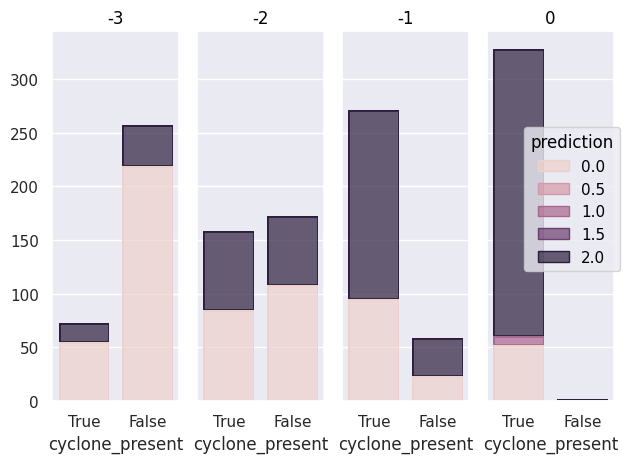

,time,timestep,cyclone_present,prediction
0,1999-07-21,-3,False,0
1,1999-07-21,-2,False,0
2,1999-07-21,-1,False,0
3,1999-07-21,0,False,0
4,1999-10-10,-3,False,0
...,...,...,...,...
1315,2012-01-10,0,True,2
1316,2012-01-11,-3,False,0
1317,2012-01-11,-2,False,2
1318,2012-01-11,-1,False,2


In [86]:
is_cyclone_there = distances.max(['longitude','latitude']).interp(time=ds_attrs.time).notnull().to_series().rename('cyclone_present').reset_index()
is_cyclone_there['prediction'] = ds_attrs.prediction.to_series().reset_index().prediction

# is_cyclone_there.groupby(['cyclone_present','prediction','timestep']).time.count()
# sns.countplot('column1', data=df)

(so.Plot(is_cyclone_there,  x='cyclone_present', color='prediction')
.add(so.Bar(), so.Count(),so.Stack())
.facet(col='timestep').show()
)
is_cyclone_there

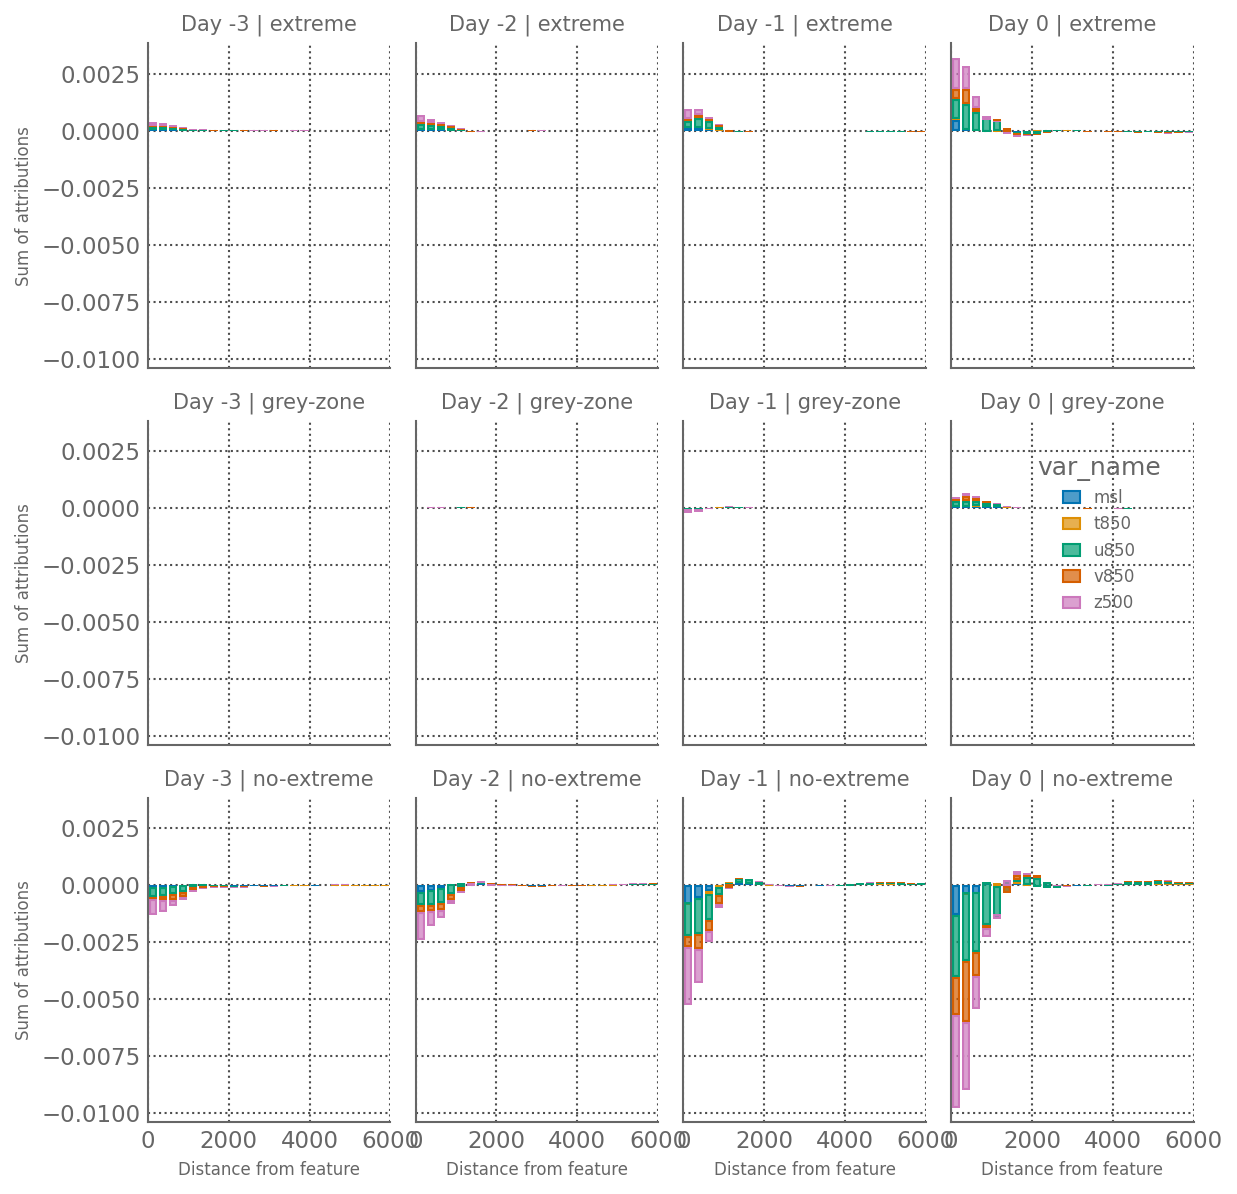

In [89]:
summed_attrs# summed_attrs = df_.groupby(['timestep','feature','var_name',pd.cut(df_.features_distance, np.arange(0,10000,200))]).attributions.sum().reset_index()
summed_attrs['features_distance'] = [k.mid for k in summed_attrs.distances]
# summed_attrs
plot = (so.Plot(summed_attrs, x='features_distance', y='attributions', color='var_name')
 .add(so.Bar(),so.Stack())
 .facet(col='timestep',row='class_id')
 .layout(size=(8,8))
 .theme(plt.style.library["robin"])
 .theme({'axes.grid':True, 'grid.color':'.3'})
 .limit(x=(0,6000))
 .label(x='Distance from feature', col='Day', y='Sum of attributions',)
 .show()
#  .share(x=True, y=False)
)

In [117]:
predictions = final_ds.attributions.sum(['longitude','latitude','var_name']).argmax('class_id')

In [120]:
predictions.to_series().value_counts()

attributions
2    1150
1     116
0      54
Name: count, dtype: int64

In [110]:
ds_.sum('var_name').attributions.sum(['longitude','latitude']).idxmax('class_id')

<xarray.DataArray 'class_id' (time: 274)> Size: 2kB
array(['grey-zone', 'extreme', 'extreme', 'extreme', 'extreme', 'extreme',
       'extreme', 'extreme', 'extreme', 'extreme', 'extreme', 'extreme',
       'no-extreme', 'extreme', 'extreme', 'extreme', 'extreme',
       'extreme', 'extreme', 'extreme', 'extreme', 'extreme', 'extreme',
       'extreme', 'extreme', 'grey-zone', 'no-extreme', 'grey-zone',
       'extreme', 'extreme', 'extreme', 'extreme', 'extreme', 'extreme',
       'no-extreme', 'extreme', 'no-extreme', 'no-extreme', 'grey-zone',
       'extreme', 'extreme', 'extreme', 'extreme', 'extreme', 'extreme',
       'extreme', 'extreme', 'no-extreme', 'extreme', 'grey-zone',
       'extreme', 'extreme', 'extreme', 'extreme', 'extreme', 'extreme',
       'extreme', 'extreme', 'extreme', 'extreme', 'no-extreme',
       'extreme', 'extreme', 'extreme', 'extreme', 'extreme', 'extreme',
       'extreme', 'extreme', 'extreme', 'extreme', 'grey-zone', 'extreme',
       'no-extreme', 'extreme', 'extreme', 'extreme', 'extreme',
       'extreme', 'extreme', 'extreme', 'extreme', 'extreme', 'extreme',
       'grey-zone', 'extreme', 'extreme', 'extreme', 'extreme',
       'no-extreme', 'no-extreme', 'extreme', 'extreme', 'no-extreme',
       'grey-zone', 'no-extreme', 'no-extreme', 'extreme', 'extreme',
       'extreme', 'extreme', 'extreme', 'extreme', 'extreme', 'extreme',
       'extreme', 'extreme', 'extreme', 'extreme', 'extreme', 'extreme',
...
       'extreme', 'extreme', 'grey-zone', 'grey-zone', 'grey-zone',
       'extreme', 'extreme', 'extreme', 'extreme', 'extreme', 'extreme',
       'extreme', 'extreme', 'extreme', 'extreme', 'extreme', 'extreme',
       'extreme', 'no-extreme', 'extreme', 'extreme', 'extreme',
       'extreme', 'extreme', 'extreme', 'extreme', 'extreme', 'extreme',
       'extreme', 'extreme', 'extreme', 'grey-zone', 'no-extreme',
       'grey-zone', 'grey-zone', 'grey-zone', 'grey-zone', 'extreme',
       'extreme', 'extreme', 'extreme', 'extreme', 'extreme', 'extreme',
       'no-extreme', 'extreme', 'extreme', 'grey-zone', 'extreme',
       'extreme', 'extreme', 'grey-zone', 'no-extreme', 'grey-zone',
       'grey-zone', 'extreme', 'extreme', 'extreme', 'extreme', 'extreme',
       'extreme', 'extreme', 'extreme', 'extreme', 'extreme',
       'no-extreme', 'grey-zone', 'grey-zone', 'extreme', 'grey-zone',
       'grey-zone', 'extreme', 'extreme', 'extreme', 'grey-zone',
       'extreme', 'no-extreme', 'grey-zone', 'extreme', 'extreme',
       'extreme', 'extreme', 'extreme', 'extreme', 'grey-zone',
       'no-extreme', 'grey-zone', 'no-extreme', 'grey-zone', 'grey-zone',
       'extreme', 'extreme', 'extreme', 'extreme', 'extreme', 'extreme',
       'extreme', 'no-extreme', 'extreme', 'extreme', 'extreme',
       'extreme', 'extreme', 'extreme', 'extreme'], dtype=object)
Coordinates:
  * time      (time) datetime64[ns] 2kB 1999-07-21 1999-10-10 ... 2012-01-11
    timestep  int64 8B -3

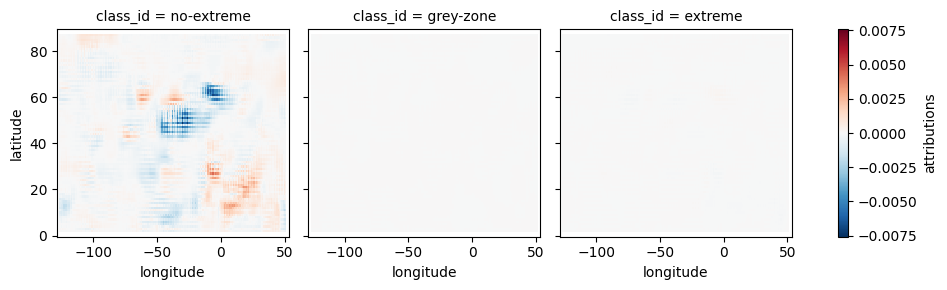

In [103]:
ds_ = ds_attrs.sel(timestep=-3)
ds_ =ds_.where(ds_.prediction==0, drop=True)
ds_.sum('var_name').isel(time=0).attributions.rolling(longitude=5,latitude=5,center=True).mean().plot(col='class_id')

In [99]:
import torch
import torch.nn.functional as F
from captum.attr import IntegratedGradients

class WrappedModel(torch.nn.Module):
    def __init__(self, model, timestep, class_idx):
        super().__init__()
        self.model = model
        self.timestep = timestep
        self.class_idx = class_idx

    def forward(self, x):
        out = self.model(x)  # shape: [batch_size, 12]
        out = out.view(-1, 4, 3)  # reshape to [batch, timesteps, classes]
        probs = F.softmax(out, dim=2)  # softmax over classes per timestep
        return probs[:, self.timestep, self.class_idx]  # shape: [batch_size]


wrapped_model = WrappedModel(lightning_model.model, timestep=2, class_idx=2)
ig = IntegratedGradients(wrapped_model)
tensor_in = torch.Tensor(ds_test_extract.features.values).requires_grad_()

input_tensor = tensor_in.requires_grad_()  # important!
attributions = ig.attribute(input_tensor).detach()
da_attrs = xr.DataArray(attributions, dims = ['timestep','var_name','latitude','longitude'], 
                            coords= dict(timestep=np.arange(1,steps+1),var_name=ds_test_extract.var_name, latitude=ds_test_extract.latitude, longitude=ds_test_extract.longitude))

In [109]:
attributions = ig.attribute(torch.zeros_like(input_tensor)).detach()


In [110]:
da_attrs.sum('var_name').sum(['longitude','latitude'])

<xarray.DataArray (timestep: 4)> Size: 16B
array([0., 0., 0., 0.], dtype=float32)
Coordinates:
  * timestep  (timestep) int64 32B 1 2 3 4

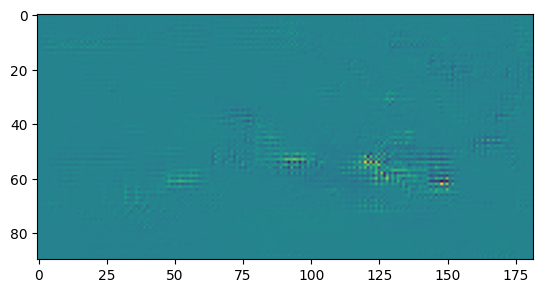

In [95]:
import matplotlib.pyplot as plt
plt.imshow(attributions.sum(dim=1)[3])

In [72]:
da_attrs.sum('var_name').sum(['longitude','latitude'])

<xarray.DataArray (class_id: 3, timestep: 4)> Size: 48B
array([[ 0.20134018,  0.09004142, -0.0354633 , -0.5514695 ],
       [ 0.0224504 ,  0.0295812 ,  0.03204483,  0.03101614],
       [-0.00972154,  0.00289331,  0.00362467,  0.00415142]],
      dtype=float32)
Coordinates:
  * class_id  (class_id) <U10 120B 'no-extreme' 'grey-zone' 'extreme'
  * timestep  (timestep) int64 32B 1 2 3 4